# Segmentasi Member ALL – Accor Indonesia (2025)
**Studi kasus analisis cluster: hierarkis (data set A1) → K-means (data set A2) → profiling → penamaan → prioritas**

Notebook ini mengikuti tujuh langkah di assignment. Setiap *Step* disusun dengan pola yang sama supaya mudah diikuti:

> **Tujuan** → **Mekanisme** (apa yang akan dilakukan dan kenapa, *sebelum* kode) → **Kode** → **Hasil & interpretasi** (setelah tiap output) → **Rangkuman Step**

| Step | Isi | Langkah assignment |
|---|---|---|
| 1 | Pemeriksaan dan pembersihan data | (prasyarat) |
| 2 | Pemilihan variabel pembentuk cluster | 1 |
| 3 | Cluster hierarkis pada A1 | 2 |
| 4 | K-means pada A2 | 3 |
| 5 | Perbandingan A1 vs A2, stabilitas, respesifikasi | 4 |
| 6 | Profiling segmen (perilaku, demografi, uji statistik) | 5 |
| 7 | Penamaan segmen | 6 |
| 8 | Daya tarik segmen, prioritas, usulan program | 7 |

**Tentang `fungsi_cluster.py`:** modul itu hanya berisi *alat bantu generik* (hitung VIF, jalankan linkage, uji ANOVA, dll). Semua keputusan analisis (aturan anomali, variabel terpilih, jumlah cluster, nama segmen, bobot daya tarik) **ditulis dan dijelaskan di notebook ini**, bukan disembunyikan di modul. Grafik disimpan ke folder `figures/` untuk bahan slide.

## Kamus Data & Singkatan

**Singkatan:** **ALL** = Accor Live Limitless (program loyalty) · **PMS** = Property Management System (sistem reservasi/kamar hotel) · **POS** = Point of Sale (kasir restoran/spa) · **OTA** = Online Travel Agent (agen perjalanan online) · **ADR** = Average Daily Rate (rata-rata harga kamar per malam) · **LOS** = Length of Stay (lama menginap) · **F&B** = Food & Beverage · **Stay** = satu kali kedatangan (check-in sampai check-out).

**Variabel perilaku (16)** – periode 1 Jan–31 Des 2025:

| Kelompok | Kolom | Arti | Satuan | Sumber |
|---|---|---|---|---|
| Frekuensi & durasi | `stays_per_year` | jumlah kedatangan | kali | PMS |
| | `total_nights` | total malam menginap | malam | PMS |
| | `avg_los` | rata-rata malam per kedatangan | malam | PMS |
| Harga & belanja | `adr` | rata-rata harga kamar per malam yang dibayar | Rp | PMS |
| | `room_spend` | total belanja kamar | Rp | PMS |
| | `fnb_per_stay` | rata-rata belanja F&B per kedatangan | Rp | POS |
| | `spa_per_stay` | rata-rata belanja spa/wellness per kedatangan | Rp | POS |
| | `total_spend` | total belanja (kamar + F&B + spa) | Rp | PMS + POS |
| Pola perjalanan | `weekday_pct` | % malam menginap di hari kerja | % | PMS |
| | `lead_time` | rata-rata jarak pemesanan ke kedatangan | hari | PMS |
| Kanal | `ota_pct` / `direct_pct` | % pemesanan lewat OTA / langsung (website/aplikasi ALL) | % | PMS |
| Fasilitas & aplikasi | `family_facility` | frekuensi pakai kolam renang + kids club per kedatangan | kali | POS/aplikasi |
| | `business_facility` | frekuensi pakai meeting room, business lounge, gym per kedatangan | kali | POS/aplikasi |
| | `app_sessions` | rata-rata sesi aplikasi ALL per bulan | sesi | aplikasi ALL |
| | `points_earned` | total poin ALL yang diperoleh | poin | aplikasi ALL |

**Variabel demografi/sosial ekonomi (8, hanya untuk profiling):** `age` (tahun), `gender`, `marital_status`, `num_children` (anak < 12 tahun), `education`, `occupation`, `monthly_income`, `domicile`.

In [63]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import fungsi_cluster as fc

fc.set_style()
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)
pd.options.display.float_format = "{:,.3f}".format
RANDOM_STATE = 42          # mengunci keacakan agar hasil bisa direproduksi

# Daftar variabel: bersumber dari tabel deskripsi data di soal (diketahui sebelum analisis)
BEHAVIOR_VARS = [
    "stays_per_year", "total_nights", "avg_los", "adr", "room_spend",
    "fnb_per_stay", "spa_per_stay", "total_spend", "weekday_pct", "lead_time",
    "ota_pct", "direct_pct", "family_facility", "business_facility",
    "app_sessions", "points_earned",
]
DEMO_NUMERIC = ["age", "num_children"]
DEMO_CATEGORICAL = ["gender", "marital_status", "education", "occupation", "monthly_income", "domicile"]
CATEGORY_ORDER = {                     # urutan kategori yang bermakna (untuk tabel dan grafik)
    "education": ["SMA", "Diploma", "S1", "S2/S3"],
    "monthly_income": ["< 10 juta", "10-25 juta", "25-50 juta", "> 50 juta"],
    "domicile": ["Jabodetabek", "Kota besar lain", "Luar negeri"],
}

A1_PATH = "Accor_ALL_cluster_data_set_A1.xlsx"
A2_PATH = "Accor_ALL_Cluster_data_set_A2.xlsx"
a1_raw = fc.load_dataset(A1_PATH, source="A1")
a2_raw = fc.load_dataset(A2_PATH, source="A2")
print("A1:", a1_raw.shape, "| A2:", a2_raw.shape)
print("customer_id duplikat di A1:", a1_raw.customer_id.duplicated().sum(),
      "| irisan ID A1 dan A2:", a1_raw.customer_id.isin(a2_raw.customer_id).sum())
a1_raw.head(3)

A1: (1000, 26) | A2: (1000, 26)
customer_id duplikat di A1: 0 | irisan ID A1 dan A2: 0


,customer_id,stays_per_year,total_nights,avg_los,adr,room_spend,fnb_per_stay,spa_per_stay,total_spend,weekday_pct,lead_time,ota_pct,direct_pct,family_facility,business_facility,app_sessions,points_earned,age,gender,marital_status,num_children,education,occupation,monthly_income,domicile,source
0,A1-0001,19,41,2.100,1602000,65688000,328000,125000,74295000,85.900,4,1.000,84.000,0.040,1.070,10.600,7311,37,Laki-laki,Lajang,0,Diploma,Manajer/profesional,10-25 juta,Jabodetabek,A1
1,A1-0002,2,12,6.000,1328000,15941000,1355000,594000,19840000,21.700,69,27.800,63.200,4.820,0.470,5.500,1967,42,Laki-laki,Menikah,1,S1,Pengusaha,> 50 juta,Kota besar lain,A1
2,A1-0003,17,22,1.200,1409000,31008000,259000,48000,36230000,89.900,6,0.100,89.100,0.190,1.840,8.500,3291,39,Perempuan,Menikah,0,S1,Eksekutif senior,10-25 juta,Kota besar lain,A1


**Hasil:** A1 dan A2 masing-masing 1.000 member dengan struktur kolom sama (16 perilaku + 8 demografi + `customer_id` + kolom `source` yang kita tambahkan sendiri untuk menandai asal data). Tidak ada ID ganda dan tidak ada member yang muncul di kedua file, jadi A1 dan A2 benar-benar dua sampel terpisah.

---
# Step 1. Pemeriksaan & Pembersihan Data

### Tujuan
Memastikan data layak dipakai sebelum dianalisis. Hint di soal: data diambil *apa adanya* dari tiga sistem berbeda (PMS, POS, aplikasi ALL) tanpa pembersihan.

### Kenapa ini penting untuk cluster analysis?
Ward dan K-means bekerja dengan **jarak Euclidean kuadrat**. Satu member dengan nilai absurd (misalnya spa Rp3 miliar per kedatangan) berjarak sangat jauh dari semua orang, sehingga algoritma menyisihkannya sebagai cluster sendiri. Hasilnya cluster berisi 1–3 orang yang tidak berguna untuk marketing, sementara sisa member dibagi kasar. Bukti kuantitatifnya ada di Step 5 (spesifikasi "naif").

### Empat lapis pemeriksaan
1. **Laporan kualitas data** – kolom kosong, tipe data, rentang min–maks.
2. **Uji identitas akuntansi** – apakah kolom turunan cocok dengan kolom penyusunnya?
3. **Aturan anomali berbasis logika bisnis** – nilai mustahil/placeholder dibuang.
4. **Ekstrem-tapi-valid** – nilai besar yang konsisten dipertahankan.

### 1a. Laporan kualitas data
**Mekanisme:** untuk tiap kolom kita lihat tipe, jumlah missing, jumlah nilai unik, serta nilai min dan max. Ini hanya **menyajikan** fakta, belum menyimpulkan apa pun. Kecurigaan muncul bila rentang nilai tidak masuk akal secara bisnis.

In [64]:
fc.data_quality_report(a1_raw)

,tipe,missing,n_unik,min,max
kolom,,,,,
customer_id,object,0,1000,-,-
stays_per_year,int64,0,33,1,156
total_nights,int64,0,62,1,285
avg_los,float64,0,58,1.000,71.300
adr,int64,0,791,9000,153900000
room_spend,int64,0,985,425000,923400000
fnb_per_stay,int64,0,637,62000,24877000
spa_per_stay,int64,0,425,5000,3434000000
total_spend,int64,0,986,509000,10338156000


**Hasil & interpretasi (A1):**
- **Missing = 0 di semua kolom**, tetapi ini *tidak* berarti data bersih: masalahnya ada pada sel yang terisi nilai tidak wajar.
- Rentang yang mencurigakan: `lead_time` maksimum **999** (kemungkinan kode placeholder PMS), `adr` dari **Rp9.000** sampai **Rp153,9 juta** per malam, `spa_per_stay` sampai **Rp3,4 miliar** per kedatangan (indikasi salah satuan), `avg_los` sampai **71,3 malam**, `family_facility` sampai **48 kali** per kedatangan.
- Tabel ini baru memberi *kecurigaan*; penentuan mana yang benar-benar salah dilakukan di 1c.

### 1b. Uji identitas akuntansi
**Mekanisme:** beberapa kolom adalah turunan kolom lain. Hipotesisnya dibaca dari **definisi kolom** di soal, lalu diuji ke data:

| Hipotesis | Dasar definisi |
|---|---|
| `total_nights = stays_per_year × avg_los` | total malam = jumlah kedatangan × malam per kedatangan |
| `room_spend = total_nights × adr` | belanja kamar = malam × harga per malam |
| `total_spend = room_spend + (fnb + spa) × stays` | definisi di soal: kamar + F&B + spa |
| `points_earned / total_spend` konstan? | hint soal: poin dihitung otomatis dari nilai transaksi |
| `ota_pct + direct_pct ≤ 100` | dua kanal tidak boleh melebihi 100% |

Untuk setiap baris dihitung **rasio = sisi kiri ÷ sisi kanan**; bila persamaan benar, rasio ≈ 1. Lalu diringkas:
- **median rasio** → gambaran tipikal (median tahan terhadap segelintir baris ekstrem),
- **toleransi** → seberapa jauh dari 1 masih dianggap cocok (ketat ±1% untuk uang, longgar ±15% untuk malam karena ada selisih antar-sistem; angka ini adalah pilihan penilaian, bukan hukum statistik),
- **% dalam toleransi** → persentase baris yang rasionya masuk rentang itu.

Untuk poin, rumus tarifnya tidak diketahui, jadi pertanyaannya diubah menjadi "apakah rasionya sama untuk semua member?".

In [65]:
# Contoh perhitungan rasio pada 3 baris pertama (agar mekanismenya terlihat)
d = a1_raw.head(3).copy()
contoh = pd.DataFrame({
    "stays x avg_los": d.stays_per_year * d.avg_los, "total_nights": d.total_nights,
    "rasio malam": d.total_nights / (d.stays_per_year * d.avg_los),
    "rasio kamar (room/(nights x adr))": d.room_spend / (d.total_nights * d.adr),
    "rasio poin (points/total_spend)": d.points_earned / d.total_spend,
}, index=d.customer_id)
contoh.style.format("{:,.4f}")

,stays x avg_los,total_nights,rasio malam,rasio kamar (room/(nights x adr)),rasio poin (points/total_spend)
customer_id,,,,,
A1-0001,nan,nan,nan,nan,nan
A1-0002,nan,nan,nan,nan,nan
A1-0003,nan,nan,nan,nan,nan


**Hasil:** untuk member A1-0001: 19 stay × 2,1 malam = 39,9 vs `total_nights` 41 → rasio **1,028**; rasio kamar **1,0001** (hampir persis); rasio poin ≈ **0,0001**. Satu baris saja sudah memperlihatkan pola: malam cocok kira-kira, uang cocok hampir persis, poin = tarif tetap.

In [66]:
# Identitas didefinisikan di sini (bukan di modul): nama -> (fungsi rasio, toleransi, jenis uji)
IDENTITIES = {
    "total_nights = stays x avg_los":
        (lambda d: d.total_nights / (d.stays_per_year * d.avg_los), 0.15, "sama_dengan_1"),
    "room_spend = total_nights x adr":
        (lambda d: d.room_spend / (d.total_nights * d.adr), 0.01, "sama_dengan_1"),
    "total_spend = room + (fnb + spa) x stays":
        (lambda d: d.total_spend / (d.room_spend + (d.fnb_per_stay + d.spa_per_stay) * d.stays_per_year), 0.01, "sama_dengan_1"),
    "points_earned / total_spend (rasio tetap?)":
        (lambda d: d.points_earned / d.total_spend, 0.20, "konstan"),
    "(ota_pct + direct_pct)/100 <= 1":
        (lambda d: (d.ota_pct + d.direct_pct) / 100, 0, "maks_1"),
}
ident = fc.check_identities(a1_raw, IDENTITIES)
ident.style.format({"median_rasio": "{:.5f}", "rasio_min": "{:.5f}", "rasio_maks": "{:.5f}", "pct_dalam_toleransi": "{:.1f}"})

,median_rasio,rasio_min,rasio_maks,toleransi,pct_dalam_toleransi
identitas,,,,,
total_nights = stays x avg_los,1.00000,0.66667,1.33333,+-15%,95.1
room_spend = total_nights x adr,1.00000,0.99856,1.00120,+-1%,100.0
total_spend = room + (fnb + spa) x stays,1.00000,0.99804,1.00156,+-1%,100.0
points_earned / total_spend (rasio tetap?),0.00010,0.00008,0.00011,+-20% dari median,100.0
(ota_pct + direct_pct)/100 <= 1,0.92900,0.85000,1.00000,<= 1,100.0


**Hasil & interpretasi (A1):**
- **Kamar dan total belanja:** rasio median 1,00 dan **100% baris lolos** pada toleransi ±1% → `room_spend` dan `total_spend` adalah **turunan** dari kolom penyusunnya (informasinya redundan).
- **Poin:** rasio konstan di **100%** baris (median ≈ 0,0001, yaitu **1 poin per Rp10.000**) → `points_earned` hanyalah `total_spend` dengan skala lain.
- **Total malam:** hanya **95,1%** baris lolos pada ±15%; rasionya berkisar 0,67–1,33. Hubungannya kuat tetapi tidak persis. Penyebab selisih belum diketahui (bukan sekadar pembulatan `avg_los`: contoh A1-0003, 17 stay dengan `avg_los` 1,2 hanya bisa menghasilkan ≤ 21,25 malam, padahal `total_nights` = 22), jadi tidak diklaim penyebabnya. Fungsi uji ini bersifat **diagnosis**, tidak membuang baris.
- **Kanal:** median (ota + direct) sekitar 93% dan tak pernah melebihi 100% → ada kanal lain (telepon, walk-in), datanya wajar.
- **Implikasi untuk Step 2:** `total_spend`, `room_spend`, `points_earned`, dan `total_nights` tidak membawa informasi baru.

### 1c. Aturan anomali (logika bisnis)
**Mekanisme:** nilai ditandai anomali bila **mustahil atau jelas salah catat secara bisnis**, *bukan* sekadar jauh dari rata-rata (aturan statistik seperti "z-score > 3" akan membuang member VIP yang nilainya asli). Setiap aturan di bawah ditulis lengkap dengan alasannya. Batas angkanya adalah **keputusan penilaian** kita; tingkat kekokohannya berbeda-beda, dan itu dijelaskan setelah tabel.

In [67]:
# Aturan anomali: nama -> (fungsi penanda baris, alasan bisnis)
ANOMALY_RULES = {
    "lead_time_999":    (lambda d: d.lead_time >= 999,
                         "lead_time = 999: kode placeholder PMS, bukan angka riil (rentang wajar 0-362 hari)"),
    "nights_gt_365":    (lambda d: d.total_nights > 365,
                         "total_nights > 365: mustahil dalam 1 tahun"),
    "avg_los_gt_30":    (lambda d: d.avg_los > 30,
                         "avg_los > 30 malam per stay: pola long-stay/corporate housing, bukan hotel reguler (paling bisa diperdebatkan)"),
    "spa_unit_error":   (lambda d: d.spa_per_stay > 1e9,
                         "spa_per_stay > Rp1 miliar per stay: indikasi salah satuan (x1000)"),
    "adr_gt_100jt":     (lambda d: d.adr > 1e8,
                         "ADR > Rp100 juta per malam: tidak realistis untuk hotel Accor Indonesia"),
    "adr_lt_100rb":     (lambda d: d.adr < 1e5,
                         "ADR < Rp100 ribu per malam: di bawah harga kamar terendah Accor"),
    "family_fac_gt_20": (lambda d: d.family_facility > 20,
                         "family_facility > 20 kali per stay: tidak wajar"),
}
pd.DataFrame({k: v[1] for k, v in ANOMALY_RULES.items()}, index=["alasan"]).T

,alasan
lead_time_999,"lead_time = 999: kode placeholder PMS, bukan angka riil (rentang wajar 0-362 hari)"
nights_gt_365,total_nights > 365: mustahil dalam 1 tahun
avg_los_gt_30,"avg_los > 30 malam per stay: pola long-stay/corporate housing, bukan hotel reguler (paling bisa diperdebatkan)"
spa_unit_error,spa_per_stay > Rp1 miliar per stay: indikasi salah satuan (x1000)
adr_gt_100jt,ADR > Rp100 juta per malam: tidak realistis untuk hotel Accor Indonesia
adr_lt_100rb,ADR < Rp100 ribu per malam: di bawah harga kamar terendah Accor
family_fac_gt_20,family_facility > 20 kali per stay: tidak wajar


In [68]:
flag1, flag2 = fc.flag_by_rules(a1_raw, ANOMALY_RULES), fc.flag_by_rules(a2_raw, ANOMALY_RULES)
pd.DataFrame({"A1": flag1.sum(), "A2": flag2.sum()}).rename(index={"any": "BARIS UNIK yang kena (any)"})

,A1,A2
lead_time_999,1,1
nights_gt_365,0,1
avg_los_gt_30,3,3
spa_unit_error,1,0
adr_gt_100jt,1,1
adr_lt_100rb,2,3
family_fac_gt_20,1,0
BARIS UNIK yang kena (any),9,8


**Hasil & interpretasi:**
- Baris "BARIS UNIK" adalah jumlah member yang dibuang. Satu baris bisa melanggar lebih dari satu aturan, jadi **jumlah pelanggaran per aturan boleh lebih besar dari jumlah baris unik** (di A2 ada kasus seperti itu).
- **Kekokohan batas:** *kuat* → `lead_time = 999` (kode sistem), `total_nights > 365` (mustahil fisik), `spa > Rp1 miliar` (jauh di luar semua baris lain). *Cukup kuat tapi tetap penilaian* → ADR < Rp100 ribu / > Rp100 juta, `family_facility > 20`. *Paling bisa diperdebatkan* → `avg_los > 30`: baris-barisnya konsisten secara internal dan mungkin tamu long-stay nyata; dibuang karena bukan pola hotel reguler dan akan menarik cluster sendiri (dampaknya hanya 3 dari 1.000 member).

In [69]:
a1, removed1 = fc.split_flagged(a1_raw, flag1)
a2, removed2 = fc.split_flagged(a2_raw, flag2)
print(f"A1: {len(a1_raw)} -> {len(a1)} (dibuang {len(removed1)})  |  A2: {len(a2_raw)} -> {len(a2)} (dibuang {len(removed2)})")
cols_show = ["customer_id", "stays_per_year", "avg_los", "adr", "spa_per_stay", "lead_time", "family_facility", "num_children", "alasan"]
display(removed1[cols_show]); display(removed2[cols_show])

A1: 1000 -> 991 (dibuang 9)  |  A2: 1000 -> 992 (dibuang 8)


,customer_id,stays_per_year,avg_los,adr,spa_per_stay,lead_time,family_facility,num_children,alasan
35,A1-0036,4,57.000,1916000,61000,107,0.130,0,avg_los_gt_30
44,A1-0045,28,2.400,9000,13000,20,0.300,0,adr_lt_100rb
52,A1-0053,3,66.900,1655000,59000,74,0.070,1,avg_los_gt_30
405,A1-0406,30,1.700,38000,23000,17,0.510,1,adr_lt_100rb
626,A1-0627,3,2.700,3357000,3434000000,26,0.590,1,spa_unit_error
779,A1-0780,3,1.900,153900000,225000,55,1.600,2,adr_gt_100jt
857,A1-0858,3,3.900,857000,734000,999,1.620,1,lead_time_999
934,A1-0935,4,71.300,1210000,17000,66,0.090,0,avg_los_gt_30
953,A1-0954,8,2.200,1049000,49000,6,48.000,0,family_fac_gt_20


,customer_id,stays_per_year,avg_los,adr,spa_per_stay,lead_time,family_facility,num_children,alasan
331,A2-0332,4,80.900,1532000,31000,87,0.140,1,avg_los_gt_30
411,A2-0412,4,76.800,1566000,117000,74,0.180,0,avg_los_gt_30
452,A2-0453,7,1.600,582000,25000,999,0.250,0,lead_time_999
559,A2-0560,7,2.200,142500000,28000,10,0.070,0,adr_gt_100jt
602,A2-0603,2,365.000,761000,19000,8,0.490,0,"nights_gt_365, avg_los_gt_30"
804,A2-0805,31,1.100,47000,14000,12,0.300,0,adr_lt_100rb
846,A2-0847,38,1.200,45000,18000,13,0.690,1,adr_lt_100rb
983,A2-0984,39,1.100,2000,19000,5,0.260,1,adr_lt_100rb


**Hasil & interpretasi:** A1 menjadi **991** member dan A2 **992** (total 17 baris dibuang, ±0,85%). Setiap baris yang dibuang tercatat lengkap dengan alasannya (kolom `alasan`), sehingga pembersihan dapat diaudit. Contoh pendukung: baris A1-0954 (`family_facility` = 48) memiliki `num_children` = 0, jadi memang tidak masuk akal sebagai pemakaian kids club.

### 1d. Ekstrem-tapi-valid → dipertahankan
**Mekanisme:** ada member yang nilainya besar tetapi **konsisten secara internal** (lolos uji identitas) dan **masuk akal secara bisnis**. Mereka dianggap *perilaku nyata* (bahkan kandidat segmen bernilai tinggi), sehingga **tidak dibuang**; efek distribusi miringnya ditangani lewat transformasi log di Step 2. Aturan pembeda:

> **Dibuang** bila nilainya mustahil/tidak konsisten (data salah). **Dipertahankan** bila ekstrem tetapi konsisten (data benar).

In [70]:
EKSTREM_RULES = {
    "sangat_sering_menginap": (lambda d: d.stays_per_year > 52, "> 52 stay/tahun (lebih dari 1 stay per minggu)"),
    "ultra_luxury":           (lambda d: (d.adr > 1.5e7) & (d.adr <= 1e8), "ADR Rp15-100 juta per malam"),
}
ext = fc.flag_by_rules(a1, EKSTREM_RULES)
tampil = a1[ext["any"]][["customer_id", "stays_per_year", "total_nights", "avg_los", "adr", "total_spend", "weekday_pct", "business_facility"]].copy()
tampil["tipe"] = np.where(ext.loc[ext["any"], "sangat_sering_menginap"], "sangat sering", "ultra-luxury")
tampil["rasio kamar"] = a1.loc[tampil.index, "room_spend"] / (a1.loc[tampil.index, "total_nights"] * a1.loc[tampil.index, "adr"])
tampil

,customer_id,stays_per_year,total_nights,avg_los,adr,total_spend,weekday_pct,business_facility,tipe,rasio kamar
31,A1-0032,139,153,1.100,2237000,373397000,72.900,9.190,sangat sering,1.000
266,A1-0270,6,19,3.100,23497000,673639000,45.900,0.420,ultra-luxury,1.000
441,A1-0446,6,17,2.900,28561000,722621000,28.300,0.490,ultra-luxury,1.000
690,A1-0696,8,22,2.700,23484000,790568000,39.700,0.180,ultra-luxury,1.000
774,A1-0781,140,154,1.100,1838000,329532000,94.700,8.330,sangat sering,1.000
872,A1-0880,156,172,1.100,1648000,337900000,82.400,9.050,sangat sering,1.000


**Hasil & interpretasi:** ada 6 member di A1 yang kita pertahankan. Kolom **rasio kamar ≈ 1,00** membuktikan angkanya konsisten secara akuntansi. Profilnya juga masuk akal: yang "sangat sering" menginap memiliki `avg_los` ~1 malam, mayoritas malam di hari kerja, dan pemakaian fasilitas bisnis tinggi, jadi pelaku perjalanan dinas yang hampir tiap hari kerja menginap; yang "ultra-luxury" ber-ADR Rp23–29 juta dengan total belanja ratusan juta rupiah (Rp674–791 juta), setara dengan tarif dan jumlah malamnya.

### Rangkuman Step 1
- Data bersih: **A1 = 991, A2 = 992** member (17 baris dibuang: placeholder, salah satuan, nilai mustahil).
- Temuan kunci uji identitas: `room_spend` dan `total_spend` adalah turunan; `points_earned` = **0,0001 × total_spend** (1 poin per Rp10.000); `total_nights` ≈ stays × avg_los (95% dalam ±15%). Ini menjadi dasar seleksi variabel di Step 2.
- Missing value = 0, tetapi data tetap "kotor" karena nilai mustahil → *missing = 0 tidak sama dengan bersih*.
- Ekstrem-tapi-valid dipertahankan dan akan ditangani dengan log.
- Keputusan yang bersifat penilaian (batas anomali, toleransi identitas) ditulis eksplisit di atas, dan dampaknya hanya ±0,85% data.

---
# Step 2. Pemilihan Variabel Pembentuk Cluster  *(Langkah 1 assignment)*

### Tujuan
Menentukan variabel perilaku mana yang membentuk cluster (demografi hanya untuk profiling) dan menyiapkannya agar adil bagi algoritma jarak.

### Tiga pekerjaan
1. **Meluruskan distribusi** yang sangat miring dengan transformasi log, supaya member ekstrem tidak mendikte pembagian cluster.
2. **Membuang variabel redundan** (korelasi dan VIF), supaya satu konsep tidak terhitung berkali-kali.
3. **Standarisasi (z-score)**, supaya satuan Rp, persen, dan kali tidak saling mendominasi jarak.

Urutan selalu: **log dulu, baru z-score**.

### 2a. Skewness dan transformasi log
**Mekanisme – skewness:** ukuran kemiringan distribusi. Mendekati 0 = simetris; positif besar = *banyak orang bernilai kecil, segelintir bernilai raksasa*. Aturan yang kita pakai: **skewness > 1 → perlu log**.

**Mekanisme – log1p:** transformasi x → log(1 + x). Log mengompresi angka besar dan membuat selisih diukur secara *proporsional*: Rp1 juta → Rp2 juta dan Rp10 juta → Rp20 juta terlihat sama besar (sama-sama dua kali lipat). Itu cocok untuk uang dan frekuensi. Bentuk `1 + x` dipakai agar nilai 0 aman (log 0 tidak terdefinisi).

**Kenapa perlu?** Tanpa log, tamu ber-ADR Rp28 juta berjarak jauh dari mayoritas yang ber-ADR Rp1–2 juta, dan perbedaan itu mengalahkan semua perbedaan halus di antara 900 member lain.

In [71]:
sk = fc.skew_table(a1, BEHAVIOR_VARS, thr=1.0)
sk

,skewness,perlu_log
spa_per_stay,12.689,True
adr,10.072,True
total_spend,9.852,True
stays_per_year,9.825,True
points_earned,9.757,True
fnb_per_stay,8.903,True
room_spend,7.748,True
lead_time,5.341,True
total_nights,4.842,True
family_facility,3.994,True


**Hasil & interpretasi:** **12 dari 16 variabel** memiliki skewness > 1 (dari `avg_los` 1,35 sampai `spa_per_stay` 12,69). Empat variabel sudah cukup simetris dan tidak perlu log: `ota_pct` (0,41), `weekday_pct` (0,13), `app_sessions` (−0,17), `direct_pct` (−0,37). Variabel yang paling miring adalah yang bersifat uang (`spa_per_stay`, `adr`, `total_spend`) dan frekuensi (`stays_per_year`).

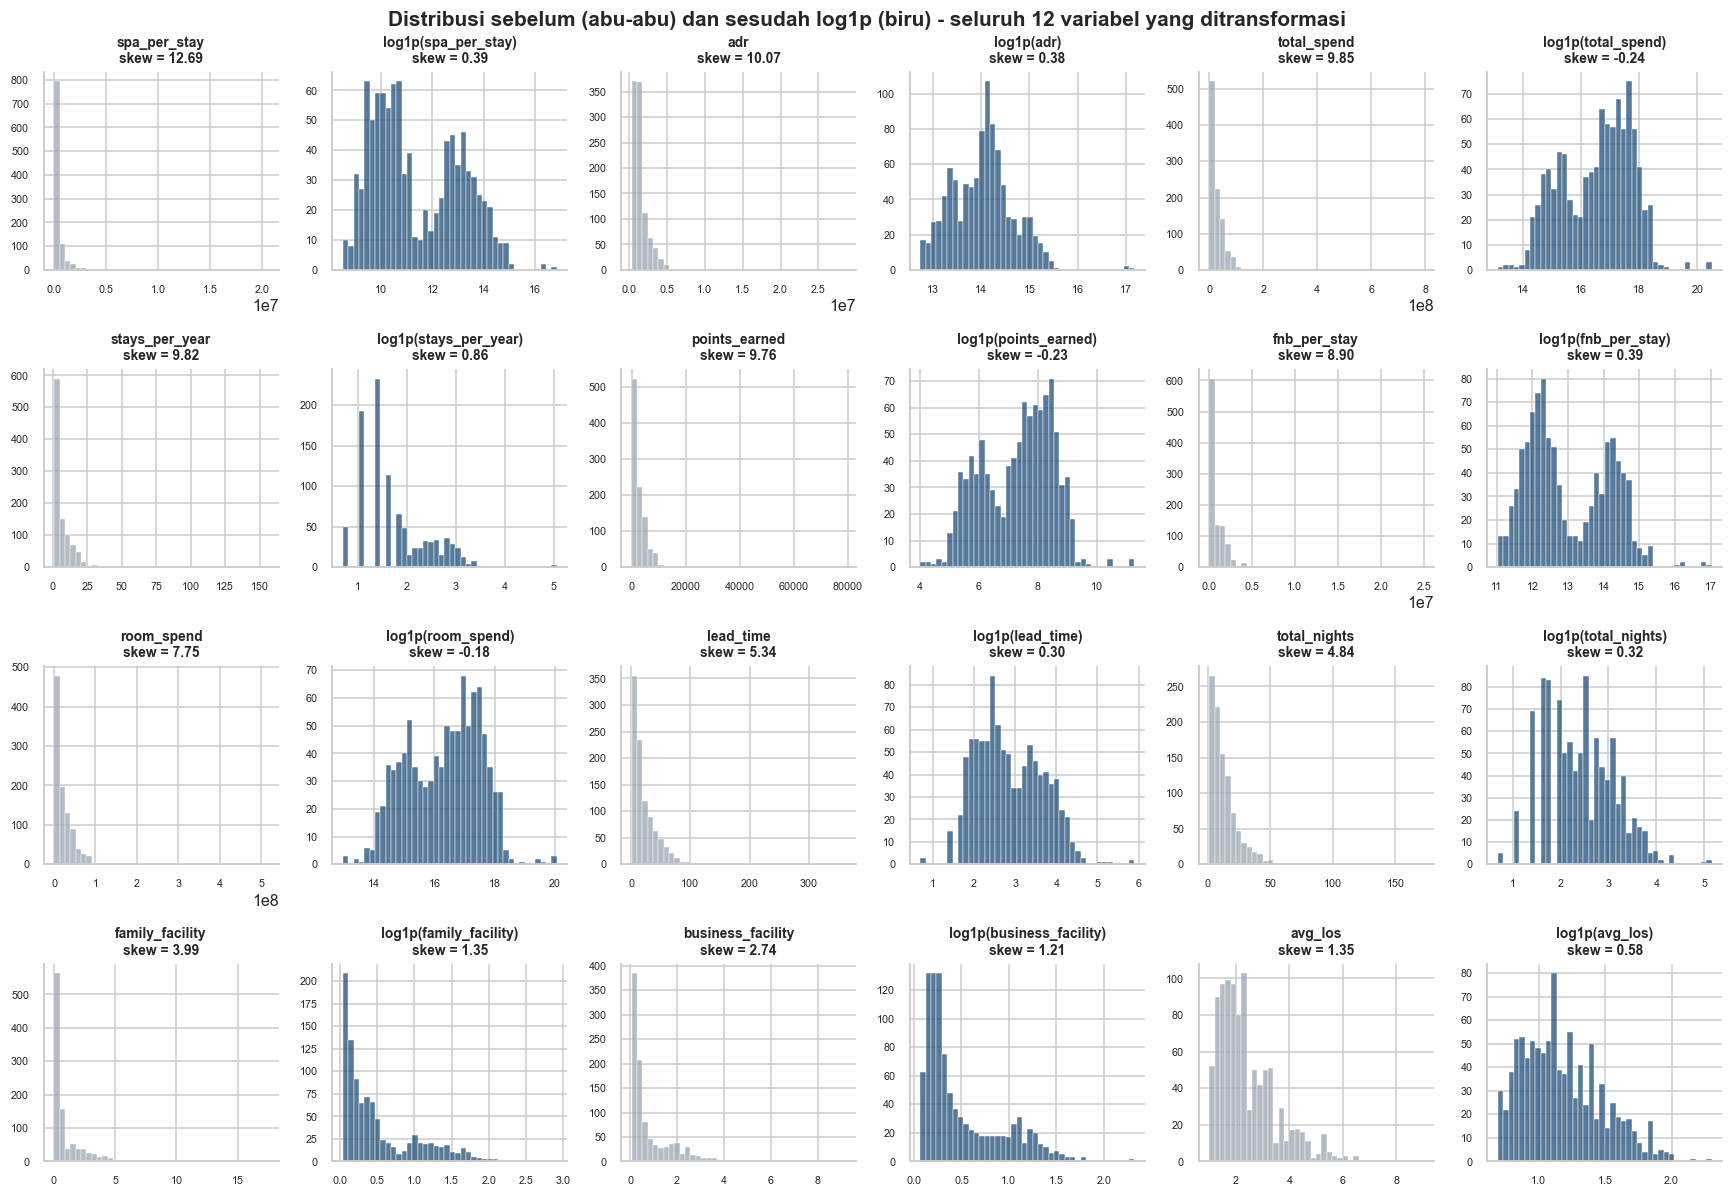

In [72]:
LOG_ALL = sk.index[sk["perlu_log"]].tolist()          # 12 variabel yang kena log
fig = fc.plot_before_after_log(a1, LOG_ALL, pairs_per_row=3)
fig.suptitle("Distribusi sebelum (abu-abu) dan sesudah log1p (biru) - seluruh 12 variabel yang ditransformasi", y=1.005, fontweight="bold")
fc.save_fig(fig, "01_transformasi_log"); plt.show()

In [73]:
tab_log = pd.DataFrame({"skew_sebelum": sk.loc[LOG_ALL, "skewness"],
                        "skew_sesudah": np.log1p(a1[LOG_ALL]).skew()})
tab_log["penurunan_%"] = (1 - tab_log["skew_sesudah"].abs() / tab_log["skew_sebelum"]) * 100
tab_log

,skew_sebelum,skew_sesudah,penurunan_%
spa_per_stay,12.689,0.388,96.942
adr,10.072,0.381,96.217
total_spend,9.852,-0.236,97.605
stays_per_year,9.825,0.861,91.232
points_earned,9.757,-0.228,97.666
fnb_per_stay,8.903,0.392,95.598
room_spend,7.748,-0.176,97.729
lead_time,5.341,0.303,94.317
total_nights,4.842,0.317,93.461
family_facility,3.994,1.349,66.233


**Hasil & interpretasi:**
- Sebelum log, histogram nyaris semuanya berupa "tiang tinggi di kiri dengan ekor sangat panjang ke kanan". Setelah log, bentuknya jauh lebih menyerupai lonceng.
- Contoh penurunan: `adr` 10,07 → **0,38**, `spa_per_stay` 12,69 → **0,39**, `stays_per_year` 9,82 → **0,86**, `lead_time` 5,34 → **0,30**.
- **Catatan jujur:** `family_facility` (3,99 → **1,35**) dan `business_facility` (2,74 → **1,21**) masih sedikit di atas 1 setelah log, karena banyak nilai mendekati nol sehingga log tidak bisa meluruskan sepenuhnya. Ini dibiarkan: penurunannya besar, dan solusi yang dihasilkan terbukti stabil (ARI = 1,00 di Step 5).
- **Temuan tambahan:** beberapa variabel tampak **bimodal (dua punuk)** setelah log, jelas pada `fnb_per_stay`, `spa_per_stay`, `room_spend`, `total_spend`, dan samar pada `adr`. Ini sinyal visual awal bahwa member terbagi atas kelompok bertarif/belanja reguler dan tinggi; log membuat struktur itu terlihat, dan kelak terkonfirmasi sebagai segmen.
- Member ekstrem **tetap ada di data**; mereka hanya tidak lagi "menarik" cluster secara berlebihan.

### 2b. Standarisasi (z-score)
**Mekanisme:** setiap variabel diubah menjadi **z = (nilai − rata-rata) ÷ simpangan baku**. Hasilnya berpusat di 0 dengan simpangan baku 1, sehingga z = +2 berarti "2 simpangan baku di atas rata-rata". Tanpa ini, variabel berskala besar (persen 0–100) akan mendominasi jarak Euclidean atas variabel berskala kecil. Fungsi `prepare_features` melakukan log (untuk variabel yang ditunjuk) lalu z-score.

In [74]:
Z_all, _ = fc.prepare_features(a1, BEHAVIOR_VARS, LOG_ALL)
Z_all.describe().loc[["mean", "std"]].round(3)

,stays_per_year,total_nights,avg_los,adr,room_spend,fnb_per_stay,spa_per_stay,total_spend,weekday_pct,lead_time,ota_pct,direct_pct,family_facility,business_facility,app_sessions,points_earned
mean,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001


**Hasil:** semua variabel kini berrata-rata 0 dan simpangan baku 1, jadi setara dalam perhitungan jarak.

### 2c. Korelasi dan multikolinearitas (VIF)
**Mekanisme – kenapa redundan itu masalah:** bila `total_spend`, `room_spend`, dan `points_earned` semuanya ikut, "nilai belanja" terhitung tiga kali dalam jarak. Konsep yang diwakili banyak variabel otomatis berbobot lebih besar, tanpa alasan bisnis.

**Dua alat deteksi:**
- **Korelasi (r):** pasangan dengan |r| ≥ 0,8 adalah kandidat redundan.
- **VIF (Variance Inflation Factor) = 1 / (1 − R²)**, dengan R² dari regresi variabel itu terhadap *semua variabel lain*. VIF menjawab "seberapa bisa variabel ini ditebak dari sisanya?". Patokan: **> 5 waspada, > 10 serius**. VIF bisa menangkap redundansi gabungan yang tidak terlihat dari korelasi dua variabel saja.

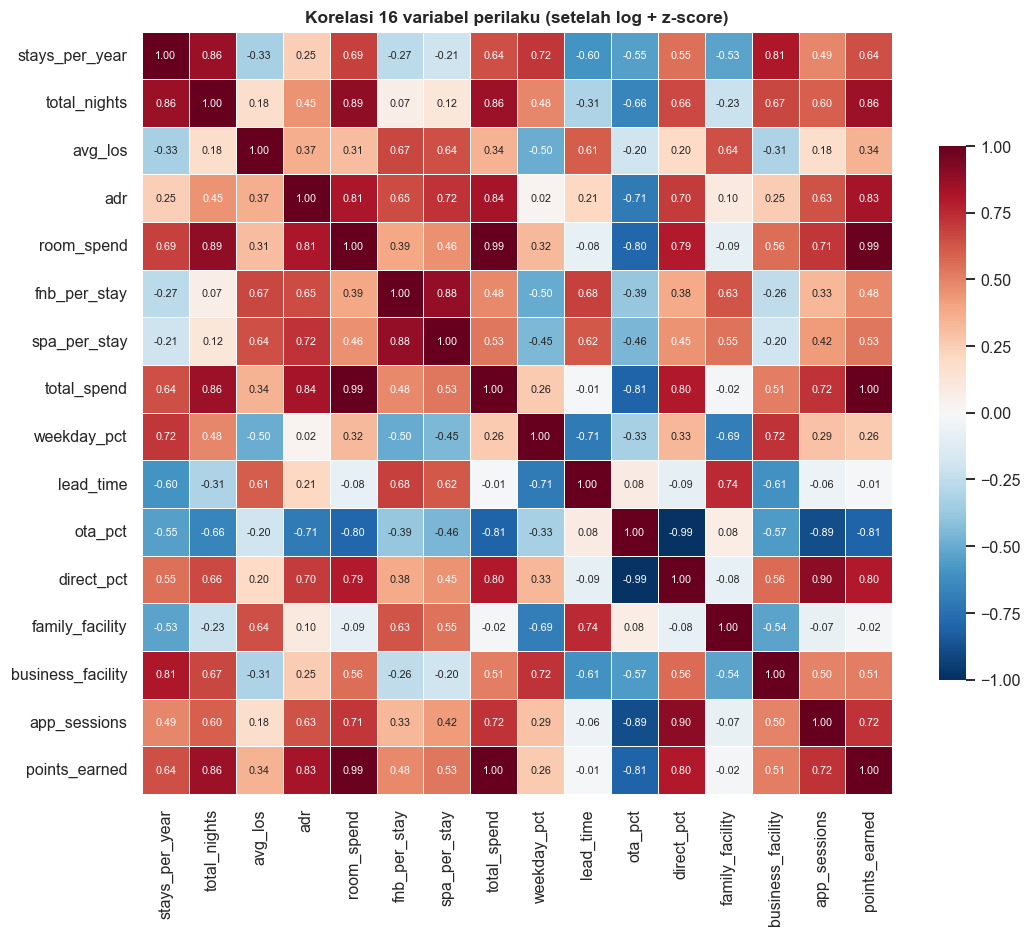

In [75]:
corr_all = Z_all.corr()
fig, ax = plt.subplots(figsize=(11, 9))
fc.plot_corr_heatmap(corr_all, ax=ax); ax.set_title("Korelasi 16 variabel perilaku (setelah log + z-score)")
fc.save_fig(fig, "02_korelasi_16var"); plt.show()

In [76]:
display(fc.high_corr_pairs(corr_all, thr=0.8))
fc.compute_vif(Z_all).to_frame()

,variabel_1,variabel_2,korelasi
0,total_spend,points_earned,0.999
1,room_spend,total_spend,0.993
2,room_spend,points_earned,0.992
3,ota_pct,direct_pct,-0.991
4,direct_pct,app_sessions,0.896
5,ota_pct,app_sessions,-0.889
6,total_nights,room_spend,0.886
7,fnb_per_stay,spa_per_stay,0.880
8,stays_per_year,total_nights,0.863
9,total_nights,points_earned,0.857


,VIF
total_spend,"1,598.852"
room_spend,"1,391.290"
points_earned,921.370
total_nights,550.056
adr,244.669
stays_per_year,101.927
direct_pct,57.789
ota_pct,56.773
avg_los,27.978
fnb_per_stay,18.474


**Hasil & interpretasi:**
- Blok merah besar di heatmap menunjukkan kelompok belanja (`total_spend`, `room_spend`, `points_earned`, `total_nights`) saling berkorelasi hampir sempurna. Pasangan terkuat: `total_spend`–`points_earned` r = **1,00**, `room_spend`–`total_spend` **0,99**, `ota_pct`–`direct_pct` **−0,99**, `direct_pct`–`app_sessions` **0,90**, `fnb_per_stay`–`spa_per_stay` **0,88**, `stays_per_year`–`total_nights` **0,86**.
- VIF ekstrem: `total_spend` ≈ **1.599**, `room_spend` ≈ 1.391, `points_earned` ≈ 921, `total_nights` ≈ 550, `adr` ≈ 245 (jauh di atas 10). Hampir seluruh informasinya sudah ada pada variabel lain.

### 2d. Keputusan variabel final
| Kelompok redundan | Dipertahankan | Alasan memilih |
|---|---|---|
| `total_spend`, `room_spend`, `points_earned` | *tidak ada* | belanja sudah terwakili `adr`, `stays`, `avg_los`, `fnb`; (`total_spend` tetap dipakai di Step 8 sebagai ukuran *nilai*) |
| `total_nights` | *tidak ada* | = stays × avg_los (komponennya dipertahankan) |
| `ota_pct` vs `direct_pct` (r = −0,99) | **`ota_pct`** | pasangan komplementer; OTA adalah isu bisnis utama di soal |
| `app_sessions` (r = 0,90 dengan kanal) | *tidak ada* | sudah terwakili kanal pemesanan |
| `spa_per_stay` vs `fnb_per_stay` (r = 0,88) | **`fnb_per_stay`** | sama-sama belanja penunjang; F&B dipakai hampir semua tamu |

> Memilih **mana yang dipertahankan** dalam sepasang variabel setara (mis. `ota_pct` vs `direct_pct`) adalah *pertimbangan bisnis*, bukan hasil hitungan.

Variabel final (9): ['stays_per_year', 'avg_los', 'adr', 'fnb_per_stay', 'weekday_pct', 'lead_time', 'ota_pct', 'family_facility', 'business_facility']
Yang di-log (7)   : ['stays_per_year', 'avg_los', 'adr', 'fnb_per_stay', 'lead_time', 'family_facility', 'business_facility']
Tidak di-log (2)  : ['weekday_pct', 'ota_pct']


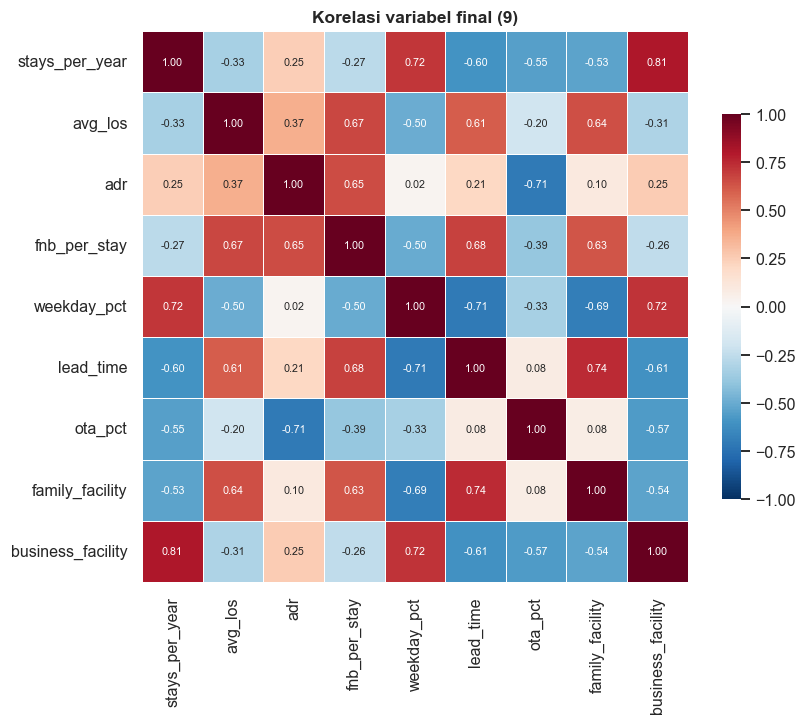

,VIF
fnb_per_stay,5.472
business_facility,3.857
stays_per_year,3.692
lead_time,3.653
ota_pct,3.604
adr,3.537
weekday_pct,3.456
family_facility,3.289
avg_los,2.222


,variabel_1,variabel_2,korelasi
0,stays_per_year,business_facility,0.809
1,lead_time,family_facility,0.745
2,weekday_pct,business_facility,0.720
3,stays_per_year,weekday_pct,0.717
4,weekday_pct,lead_time,-0.710
5,adr,ota_pct,-0.707
6,weekday_pct,family_facility,-0.695
7,fnb_per_stay,lead_time,0.684
8,avg_los,fnb_per_stay,0.668
9,adr,fnb_per_stay,0.653


In [77]:
FINAL_VARS = ["stays_per_year", "avg_los", "adr", "fnb_per_stay",      # intensitas & nilai
              "weekday_pct", "lead_time",                               # pola perjalanan
              "ota_pct",                                                # kanal pemesanan
              "family_facility", "business_facility"]                   # tujuan perjalanan
LOG_FINAL = [c for c in FINAL_VARS if c in LOG_ALL]                    # variabel final yang di-log
print("Variabel final (9):", FINAL_VARS)
print("Yang di-log (7)   :", LOG_FINAL)
print("Tidak di-log (2)  :", [c for c in FINAL_VARS if c not in LOG_FINAL])

Z1, scaler1 = fc.prepare_features(a1, FINAL_VARS, LOG_FINAL)
fig, ax = plt.subplots(figsize=(8, 6.5))
fc.plot_corr_heatmap(Z1.corr(), ax=ax); ax.set_title("Korelasi variabel final (9)")
fc.save_fig(fig, "03_korelasi_final"); plt.show()
display(fc.compute_vif(Z1).to_frame())
fc.high_corr_pairs(Z1.corr(), thr=0.6)

**Hasil & interpretasi:**
- **VIF semua di bawah 6** (tertinggi `fnb_per_stay` ≈ 5,5; lainnya 2,2–3,9). Tidak ada pasangan dengan |r| ≥ 0,85.
- Korelasi sedang yang tersisa (maksimum ≈ 0,81, mis. `stays_per_year` dengan `business_facility`) **dibiarkan** karena wajar secara bisnis (pebisnis yang sering menginap memang memakai fasilitas bisnis) dan VIF-nya aman. Tujuan seleksi bukan menghilangkan semua korelasi, melainkan menghentikan **redundansi ekstrem**.
- Dengan 9 variabel, lima dimensi perilaku terwakili: intensitas/nilai, pola perjalanan, kanal, dan tujuan perjalanan (keluarga vs bisnis).

### Rangkuman Step 2
- **12 dari 16** variabel miring (skew > 1) → di-log; sesudahnya skewness turun drastis (kecuali `family_facility` dan `business_facility` yang masih ~1,2–1,3).
- **16 → 9 variabel** pembentuk cluster: `stays_per_year`, `avg_los`, `adr`, `fnb_per_stay`, `weekday_pct`, `lead_time`, `ota_pct`, `family_facility`, `business_facility`. Tujuh di antaranya di-log; `weekday_pct` dan `ota_pct` tidak.
- VIF turun dari ribuan menjadi ≤ 5,5; korelasi tertinggi 0,81.
- Semua variabel kemudian distandarisasi (z-score). Spesifikasi yang **sama persis** dipakai untuk A1 (Step 3) dan A2 (Step 4).

---
# Step 3. Cluster Hierarkis pada Data Set A1  *(Langkah 2 assignment)*

### Tujuan
Membentuk cluster di A1 dengan metode hierarkis, lalu menentukan **(1) ukuran jarak, (2) metode aglomerasi, (3) jumlah cluster** dengan justifikasi statistik dan bisnis.

### Mekanisme cluster hierarkis (aglomeratif)
1. Mulai dari **991 cluster**, satu per member.
2. Cari dua cluster **terdekat**, gabungkan.
3. Ulangi sampai tinggal **satu** cluster berisi semua orang.
4. Seluruh riwayat penggabungan disimpan sebagai pohon (**dendrogram**). Kita lalu **memotong pohon** pada jumlah cluster yang dipilih.

Keunggulannya: seluruh proses terlihat sebelum k diputuskan, dan hasilnya deterministik (tanpa titik awal acak).

### 3a. Ukuran jarak: Euclidean
**Mekanisme:** jarak Euclidean antara dua member = akar dari jumlah kuadrat selisih tiap variabel (pada nilai z-score), yaitu "jarak garis lurus" di ruang 9 dimensi. Dipilih karena (i) variabel sudah dilog dan distandarisasi sehingga selisihnya sebanding, (ii) semua variabel kontinu, (iii) metode Ward mensyaratkan jarak Euclidean.

In [78]:
# Verifikasi rumus pada dua member pertama
z_i, z_j = Z1.iloc[0], Z1.iloc[1]
contoh_jarak = pd.DataFrame({"member_0": z_i, "member_1": z_j, "selisih": z_i - z_j, "selisih^2": (z_i - z_j) ** 2})
print("Jarak manual   = akar(jumlah selisih^2) =", round(float(np.sqrt(contoh_jarak["selisih^2"].sum())), 4))
print("Jarak scipy (pdist)                     =", round(float(pdist(Z1.iloc[[0, 1]].values)[0]), 4))
contoh_jarak

Jarak manual   = akar(jumlah selisih^2) = 6.857
Jarak scipy (pdist)                     = 6.857


,member_0,member_1,selisih,selisih^2
stays_per_year,1.842,-0.950,2.792,7.796
avg_los,-0.145,2.583,-2.727,7.437
adr,0.401,0.100,0.302,0.091
fnb_per_stay,-0.259,0.987,-1.247,1.554
weekday_pct,1.267,-1.199,2.466,6.083
lead_time,-1.583,1.741,-3.324,11.050
ota_pct,-1.199,-0.317,-0.881,0.777
family_facility,-0.938,2.461,-3.399,11.555
business_facility,0.521,-0.301,0.823,0.677


**Hasil:** hitungan manual dan `pdist` memberi angka yang sama. Variabel dengan selisih terbesar (kuadratnya terbesar) menyumbang paling banyak ke jarak; itu sebabnya skala semua variabel harus setara (Step 2b).

### 3b. Metode aglomerasi
**Mekanisme:** setelah ada jarak antar-member, perlu aturan "jarak antar *kelompok*":

| Metode | Aturan jarak antar kelompok | Kecenderungan |
|---|---|---|
| Single | jarak **terdekat** antar dua anggota | cenderung *chaining*: satu cluster raksasa menelan titik di sekitarnya |
| Complete | jarak **terjauh** antar dua anggota | cluster kompak, seimbang |
| Average | **rata-rata** semua pasangan | di antara keduanya, tetapi peka outlier |
| Ward | gabungkan pasangan yang **menambah varians dalam-cluster paling kecil** | cluster seimbang; tujuan sama dengan K-means |

**Cophenetic correlation** = korelasi antara jarak asli antar-member dan jarak yang "tersirat" di dendrogram (makin dekat 1, dendrogram makin setia pada data). **Silhouette** = seberapa pas member berada di clusternya dibanding cluster tetangga (−1 sampai 1; > 0,5 baik).

In [79]:
cmp_link = fc.compare_linkages(Z1, k=4)
cmp_link

,cophenetic_corr,silhouette_k4,ukuran_cluster,cluster_terkecil
metode,,,,
single,0.861,0.178,"[983, 3, 3, 2]",2
complete,0.810,0.497,"[296, 296, 249, 150]",150
average,0.883,0.279,"[982, 3, 3, 3]",3
ward,0.836,0.497,"[296, 296, 249, 150]",150


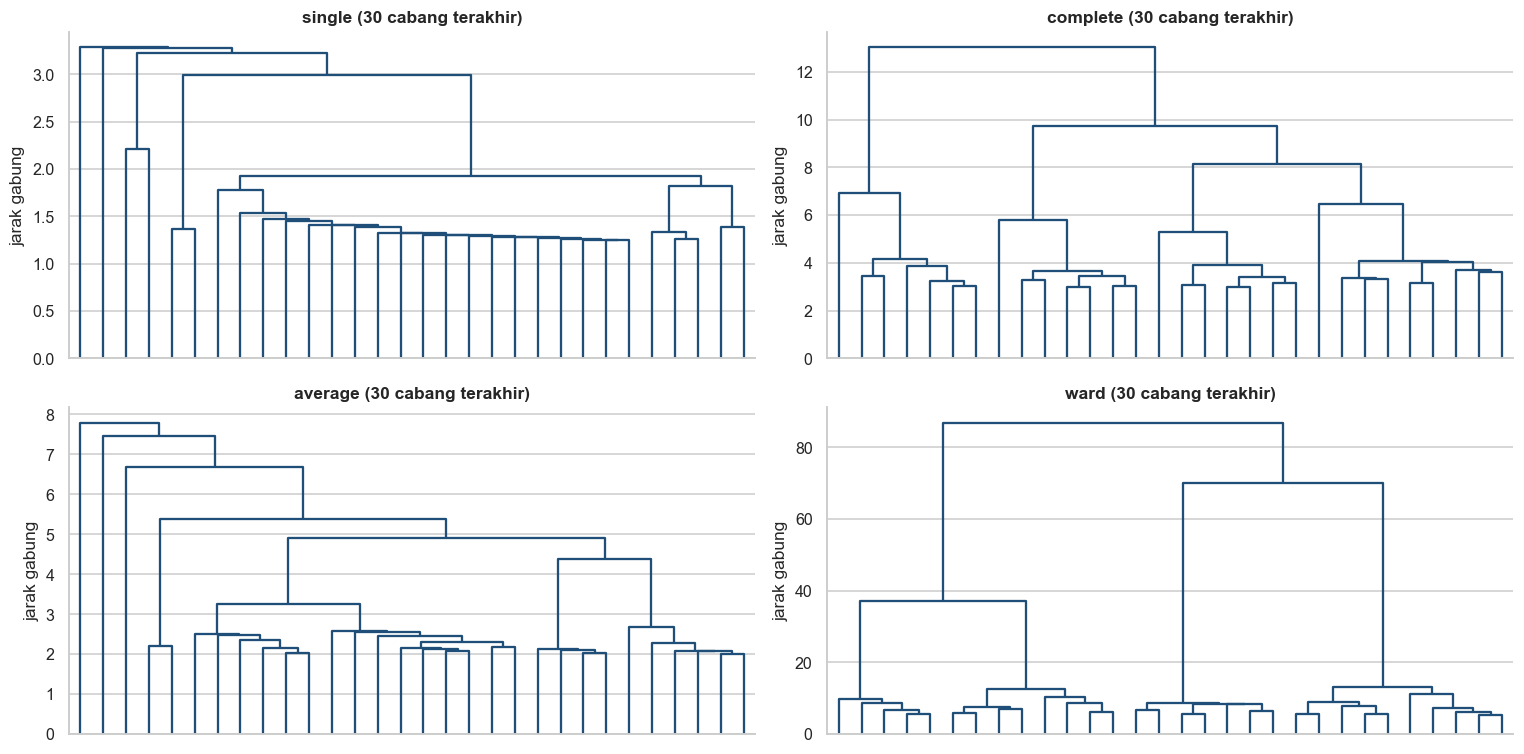

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, m in zip(axes.ravel(), ["single", "complete", "average", "ward"]):
    Lm = linkage(Z1.values, method=m, metric="euclidean")
    fc.plot_dendrogram(Lm, k=None, ax=ax, p=30, ylabel="jarak gabung")
    ax.set_title(f"{m} (30 cabang terakhir)")
plt.tight_layout(); fc.save_fig(fig, "04b_dendrogram_4_metode"); plt.show()

**Hasil & interpretasi:**
- **Single** (cophenetic 0,861) dan **average** (0,883) menghasilkan satu cluster raksasa (983 dan 982 member) plus cluster berisi 2–3 orang: efek *chaining*. Di dendrogramnya terlihat pola **"tangga"**: titik-titik outlier (cabang tunggal di sisi kiri) menempel **satu per satu** pada gumpalan utama, sementara hampir semua member sudah menyatu rendah dalam satu blok besar. Silhouette-nya rendah (0,18 dan 0,28). Untuk segmentasi marketing, hasil ini tidak berguna.
- **Complete** dan **Ward** memperlihatkan **empat blok besar** yang jelas terpisah di dendrogramnya dan menghasilkan solusi seimbang yang **identik**: ukuran 296 / 296 / 249 / 150 dan silhouette sama (0,497).
- **Catatan:** cophenetic tertinggi justru dimiliki average (0,883), padahal hasil clusternya gagal. Jadi cophenetic **bukan penentu tunggal**; ia harus dibaca bersama ukuran cluster dan silhouette.
- **Ward dipilih.** Secara statistik di data ini complete setara, jadi alasannya konseptual: Ward meminimalkan varians dalam-cluster, tujuan yang sama dengan K-means di Step 4, sehingga perbandingan A1 vs A2 lebih "apel dengan apel".

### 3c. Dendrogram Ward
**Cara baca:** sumbu vertikal = **jarak saat dua cabang digabung**. Cabang yang menyatu di tempat rendah sangat mirip; yang menyatu di tempat tinggi berbeda jauh. Garis merah putus-putus = potongan pada k yang dipilih: jumlah garis vertikal yang terpotong = jumlah cluster. **Lompatan vertikal yang panjang** berarti dua kelompok berbeda dipaksa bergabung.

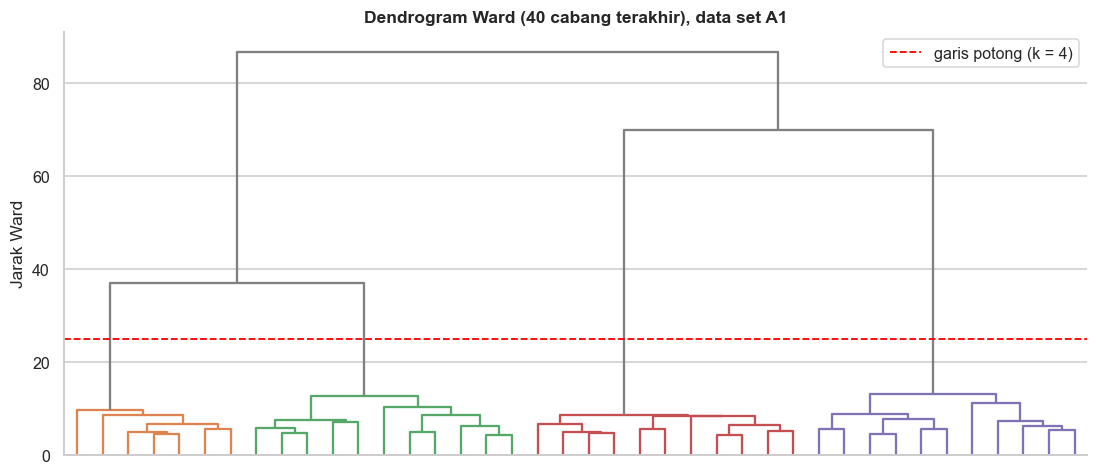

In [81]:
L = linkage(Z1.values, method="ward", metric="euclidean")
fig, ax = plt.subplots(figsize=(12, 5))
fc.plot_dendrogram(L, k=4, ax=ax, p=40, ylabel="Jarak Ward")
ax.set_title("Dendrogram Ward (40 cabang terakhir), data set A1")
fc.save_fig(fig, "04_dendrogram"); plt.show()

**Hasil & interpretasi:** di bawah garis potong (k = 4) terdapat **empat blok berwarna** yang masing-masing menyatu di jarak rendah (≤ ±13). Untuk menggabungkan *antar*-blok jaraknya melonjak: dua blok di sisi kiri baru bergabung di jarak **±37** (inilah penggabungan k = 4 → 3 dengan biaya 36,99 di tabel agglomeration), pasangan blok di sisi kanan bergabung di **±70**, dan kedua sisi bertemu di **±87**. Garis potong (±25) melewati **ruang kosong yang panjang** antara jarak ±13 dan ±37: tidak ada penggabungan yang terjadi di rentang itu, dan itulah tanda empat blok tersebut benar-benar terpisah.

### 3d. Menentukan jumlah cluster
Tidak ada satu angka sakti; kita kumpulkan beberapa bukti.

**Agglomeration schedule.** Mencatat "biaya" (jarak Ward) tiap kali dua cluster digabung. Kolom `kenaikan_pct` pada baris k menunjukkan seberapa besar biaya menggabung k → k−1 dibanding menggabung (k+1) → k. **Lonjakan besar = penggabungan itu memaksa dua kelompok yang sebenarnya berbeda.** Logikanya: berhenti *sebelum* lonjakan besar.

In [82]:
agg = fc.agglomeration_table(L, max_k=8)
agg

,biaya_gabung_berikutnya,lonjakan_vs_sebelumnya,kenaikan_pct
k,,,
8,10.327,0.616,6.338
7,11.131,0.803,7.778
6,12.685,1.554,13.964
5,13.045,0.360,2.837
4,36.986,23.941,183.531
3,69.923,32.937,89.052
2,86.747,16.824,24.061


**Hasil & interpretasi:** dari 8 sampai 5 cluster, biaya penggabungan naik kecil (+3% sampai +14%) → menggabungkan kelompok yang memang mirip. Pada **k = 4 → 3 biayanya melonjak ±184%** (dari ≈ 13 menjadi ≈ 37), lalu naik lagi ±89% pada 3 → 2. Artinya **4 adalah jumlah cluster terakhir sebelum penggabungan mulai "merusak"** struktur.

**Indeks kualitas cluster:**
- **Silhouette** (tinggi = baik), **Calinski-Harabasz** (rasio varians antar-/dalam-cluster; tinggi = baik), **Davies-Bouldin** (rata-rata tumpang tindih; **rendah** = baik), **WSS** (total kuadrat jarak ke pusat cluster; untuk grafik elbow; selalu turun saat k naik, jadi yang dicari adalah titik "tekukan").

In [83]:
ev_h = fc.evaluate_k(Z1, ks=range(2, 9), method="hier", L=L)
ev_h

,silhouette,calinski_harabasz,davies_bouldin,wss,cluster_terkecil_pct
k,,,,,
2,0.405,721.642,1.085,"5,156.481",40.262
3,0.509,"1,130.692",0.739,"2,711.890",29.869
4,0.497,"1,117.985",0.852,"2,027.907",15.136
5,0.361,885.118,1.499,"1,942.824",14.733
6,0.294,746.444,1.869,"1,862.371",11.705
7,0.296,648.428,1.689,"1,800.426",0.303
8,0.297,576.464,1.541,"1,747.099",0.303


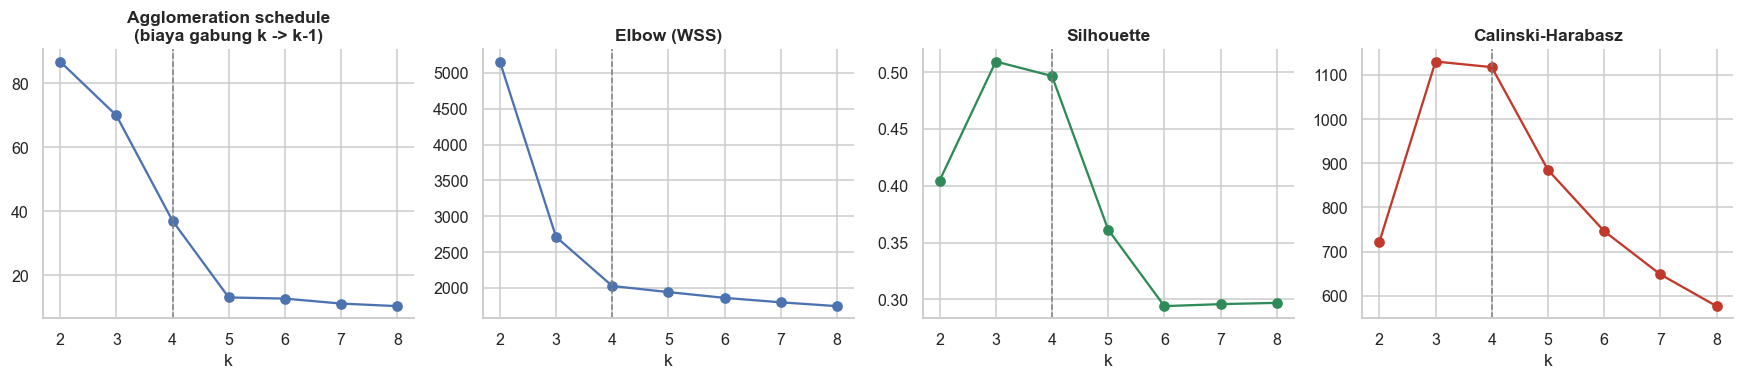

In [84]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
ks = ev_h.index
axes[0].plot(agg.index[::-1], agg["biaya_gabung_berikutnya"][::-1], "o-"); axes[0].set_title("Agglomeration schedule\n(biaya gabung k -> k-1)")
axes[1].plot(ks, ev_h["wss"], "o-"); axes[1].set_title("Elbow (WSS)")
axes[2].plot(ks, ev_h["silhouette"], "o-", color="#2e8b57"); axes[2].set_title("Silhouette")
axes[3].plot(ks, ev_h["calinski_harabasz"], "o-", color="#c0392b"); axes[3].set_title("Calinski-Harabasz")
for ax in axes: ax.axvline(4, color="grey", ls="--", lw=1); ax.set_xlabel("k")
plt.tight_layout(); fc.save_fig(fig, "05_pemilihan_k"); plt.show()

**Hasil & interpretasi:**
- **Pembacaan jujur:** secara murni statistik **k = 3 sedikit lebih unggul** (silhouette 0,509 vs 0,497; Calinski-Harabasz 1.131 vs 1.118; Davies-Bouldin 0,739 vs 0,852). Selisihnya tipis, sedangkan dari k = 4 ke k = 5 semua indeks anjlok (silhouette 0,361; Davies-Bouldin 1,499). Jadi **k = 3 dan 4 sama-sama defensible**; k ≥ 5 tidak.
- WSS melandai setelah k = 4 (tekukan elbow), konsisten dengan lonjakan agglomeration.
- Pada k ≥ 7 cluster terkecil hanya 0,3% (3 orang): itu outlier, bukan segmen.
- Karena indeks tidak menentukan antara 3 dan 4, keputusan bergantung pada (i) **lonjakan agglomeration +184%** dan (ii) **alasan bisnis**, diperiksa di bawah.

In [85]:
l3 = fcluster(L, 3, "maxclust") - 1
l4 = fcluster(L, 4, "maxclust") - 1
pd.crosstab(pd.Series(l4, name="cluster di k=4"), pd.Series(l3, name="cluster di k=3"))

cluster di k=3,0,1,2
cluster di k=4,,,
0,150,0,0
1,249,0,0
2,0,296,0
3,0,0,296


In [86]:
# Profil singkat tiap cluster k=4 (A1, Ward) untuk melihat klaster yang digabung pada k=3
profil_k4 = a1.assign(cluster=l4).groupby("cluster").agg(
    n=("customer_id", "size"),
    adr_juta=("adr", lambda s: s.mean() / 1e6),
    weekday_pct=("weekday_pct", "mean"),
    stays_per_year=("stays_per_year", "mean"),
    ota_pct=("ota_pct", "mean"),
)
profil_k4["jadi_cluster_k3"] = pd.Series(l3).groupby(l4).agg(lambda s: s.mode()[0])
profil_k4

,n,adr_juta,weekday_pct,stays_per_year,ota_pct,jadi_cluster_k3
cluster,,,,,,
0,150,3.759,41.751,4.227,12.329,0
1,249,1.342,24.851,2.542,39.065,0
2,296,0.625,50.400,3.122,76.318,1
3,296,1.542,84.724,14.716,9.953,2


pada k = 3, cluster 0 dan 1 (150 + 249 = 399 member) digabung, sedangkan dua cluster lainnya tetap utuh. Dari tabel profil di atas, kedua cluster itu sama-sama dominan akhir pekan (malam hari kerja 42% dan 25%) dan jarang menginap (4,2 dan 2,5 stay/tahun), tetapi ADR-nya berbeda jauh (Rp3,76 juta vs Rp1,34 juta) dan porsi OTA-nya juga (12% vs 39%). Jadi k = 3 menggabungkan dua kelompok dengan tarif dan kanal pemesanan yang sangat berbeda; satu program marketing tidak akan cocok untuk keduanya.


**Hasil & interpretasi:** pada k = 3, **cluster 0 dan 1 (150 + 249 = 399 member) digabung**, sedangkan dua cluster lainnya (296 dan 296) tetap utuh. Jadi yang "dikorbankan" k = 3 adalah pemisahan kelompok ber-ADR tinggi (±Rp3,7 juta) dari kelompok ber-ADR sedang (±Rp1,35 juta) yang sama-sama berorientasi liburan. Kebutuhannya berbeda sehingga satu program marketing tidak akan cocok untuk keduanya (profil rinci di Step 6–7).

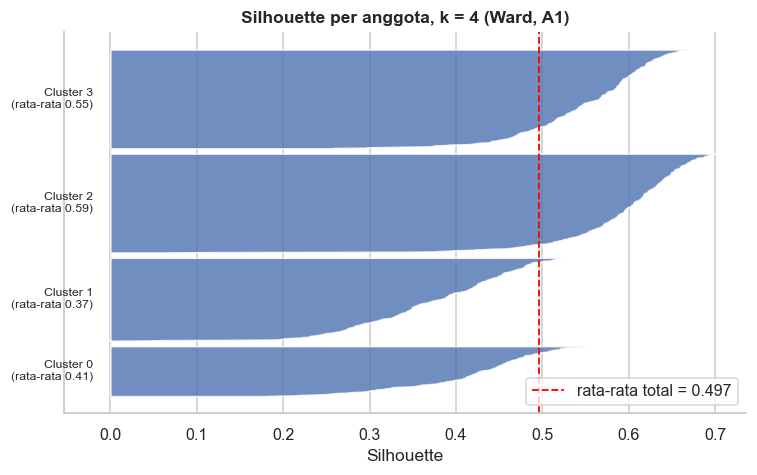

Silhouette rata-rata per cluster: {0: 0.415, 1: 0.371, 2: 0.592, 3: 0.548}
Anggota dengan silhouette negatif (salah tempat): 1 dari 991 (0.10%)


In [87]:
fig, ax = plt.subplots(figsize=(8, 4.5))
fc.plot_silhouette(Z1, l4, ax=ax)
ax.set_title("Silhouette per anggota, k = 4 (Ward, A1)")
fc.save_fig(fig, "04c_silhouette_k4"); plt.show()
sil_i = pd.Series(__import__("sklearn.metrics", fromlist=["x"]).silhouette_samples(Z1.values, l4))
print("Silhouette rata-rata per cluster:", sil_i.groupby(l4).mean().round(3).to_dict())
print(f"Anggota dengan silhouette negatif (salah tempat): {(sil_i < 0).sum()} dari {len(sil_i)} ({(sil_i < 0).mean()*100:.2f}%)")

**Hasil & interpretasi:** silhouette rata-rata per cluster: cluster 0 = **0,415**, cluster 1 = **0,371**, cluster 2 = **0,592**, cluster 3 = **0,548**. Hanya **1 dari 991** member bersilhouette negatif. Dua cluster dengan kohesi terlemah (0 dan 1) adalah **pasangan yang digabung pada k = 3**, jadi mereka memang yang paling berdekatan; namun kohesinya tetap positif dan memadai.

### Keputusan: k = 4
- **Statistik:** biaya penggabungan melonjak ±184% pada 4 → 3; seluruh indeks anjlok setelah k = 4; k = 4 hanya berselisih tipis dari k = 3 pada silhouette/CH.
- **Bisnis:** k = 3 menggabungkan dua kelompok liburan dengan kebutuhan berbeda; setiap segmen pada k = 4 berukuran ≥ 15% member, cukup besar untuk digarap dan cukup sedikit untuk dikelola.

In [88]:
K = 4
lab_h = fcluster(L, K, "maxclust") - 1
a1["cl_hier"] = lab_h
fc.size_table(lab_h)

,n,persen
0,150,15.136
1,249,25.126
2,296,29.869
3,296,29.869


### Rangkuman Step 3
- **Jarak:** Euclidean pada 9 variabel terstandarisasi.
- **Metode:** **Ward**. Single dan average gagal karena *chaining* (cluster berisi 2–3 orang); complete setara Ward di data ini, tetapi Ward lebih selaras dengan K-means.
- **Jumlah cluster: k = 4.** Dasar: lonjakan agglomeration ±184% pada 4 → 3, indeks anjlok setelah k = 4, dan alasan bisnis (k = 3 menggabung 249 + 150 member yang kebutuhannya berbeda). Jujur diakui bahwa k = 3 sedikit lebih tinggi pada silhouette/CH.
- **Hasil di A1:** 4 cluster berukuran **150, 249, 296, 296** (15,1% / 25,1% / 29,9% / 29,9%), silhouette total 0,497, hanya 1 member bersilhouette negatif.

---
# Step 4. K-means pada Data Set A2  *(Langkah 3 assignment)*

### Tujuan
Membentuk 4 cluster di A2 dengan K-means, memakai **spesifikasi yang sama persis** (variabel, variabel yang di-log, standarisasi) dan k = 4 dari Step 3.

### Kenapa dua dataset dan dua metode?
Data dibagi acak menjadi A1 dan A2. A1 dipakai untuk **eksplorasi** (menentukan k), A2 untuk **replikasi independen dengan algoritma berbeda**. Bila dua sampel dan dua algoritma menghasilkan segmen yang sama, kita punya bukti kuat bahwa segmen itu **nyata**, bukan kebetulan dari satu sampel atau satu algoritma.

### Mekanisme K-means (algoritma Lloyd)
K-means memerlukan k dari luar. Algoritmanya:
1. **Tempatkan k titik pusat (centroid) awal** (di sini: k member yang dipilih acak).
2. **Penugasan:** tiap member masuk ke centroid terdekat.
3. **Pembaruan:** centroid dipindah ke **rata-rata** anggotanya.
4. Ulangi langkah 2–3 sampai **tidak ada member yang pindah cluster** → konvergen.

Besaran yang diminimalkan: **WSS (inertia)** = total kuadrat jarak setiap member ke centroid clusternya. WSS **tidak pernah naik** antar-iterasi, sehingga algoritma pasti berhenti. Namun hasil akhirnya bergantung pada titik awal (bisa berhenti di *local optimum*), itu sebabnya dijalankan berulang (`n_init`).

In [89]:
Z2, scaler2 = fc.prepare_features(a2, FINAL_VARS, LOG_FINAL)   # spesifikasi identik dengan A1
X2 = Z2.values
print("A2 siap:", Z2.shape, "| rata-rata z ≈ 0:", np.allclose(Z2.mean(), 0, atol=1e-8), "| SD z ≈ 1:", np.allclose(Z2.std(ddof=0), 1, atol=1e-8))

A2 siap: (992, 9) | rata-rata z ≈ 0: True | SD z ≈ 1: True


### 4a. Demonstrasi algoritma langkah demi langkah
Agar mekanismenya terlihat (bukan kotak hitam), kita jalankan algoritma Lloyd yang ditulis eksplisit (`fc.lloyd_kmeans`) dari titik awal acak. **Kolom `pindah`** = jumlah member yang berganti cluster; pada iterasi 1 semua member "baru ditugaskan" sehingga `pindah` = jumlah seluruh member. **Konvergen** saat `pindah` = 0.

,pindah,wss
iterasi,,
1,992,"7,837.520"
2,164,"5,075.640"
3,175,"4,617.226"
4,174,"2,635.910"
5,3,"2,087.861"
6,0,"2,087.545"


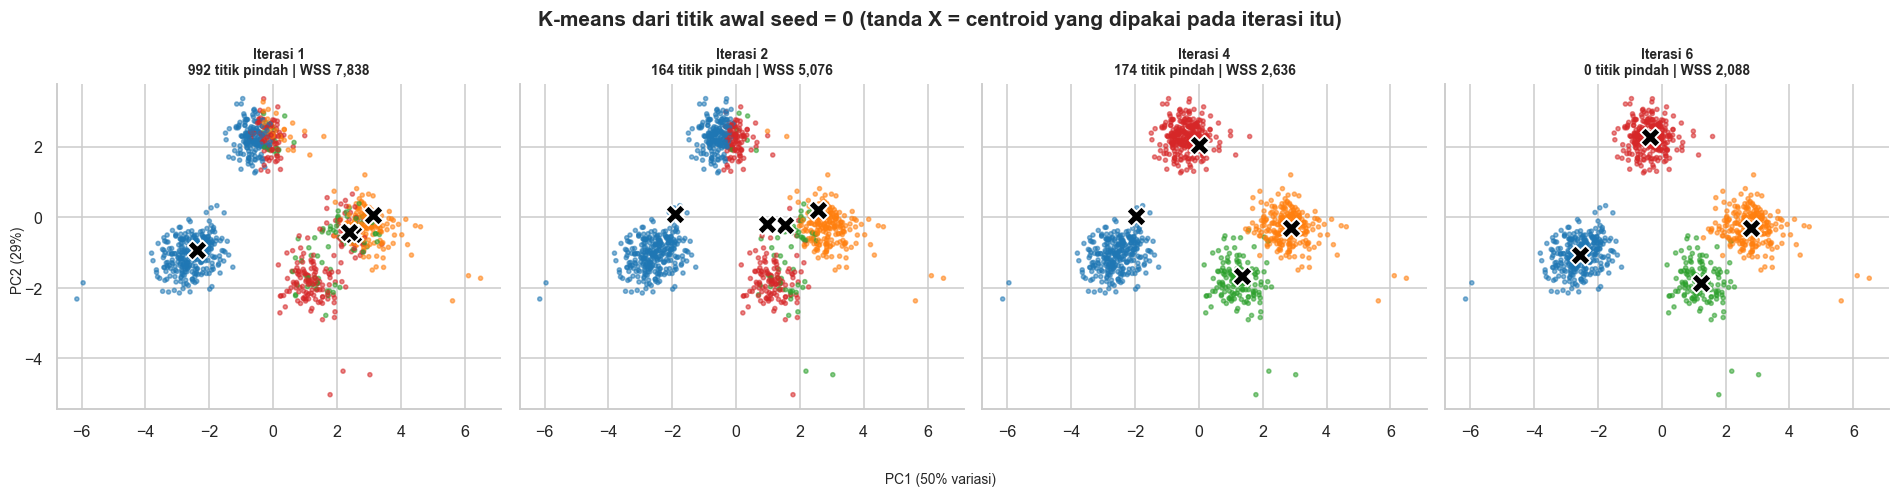

Catatan: proyeksi 2D (PCA) hanya menangkap 79% variasi data 9 dimensi; cluster yang terlihat berimpit di 2D bisa terpisah di dimensi lain.


In [90]:
def titik_awal(seed, k=4):
    rng = np.random.default_rng(seed)
    return X2[rng.choice(len(X2), k, replace=False)]      # k member acak sebagai centroid awal

hist_baik = fc.lloyd_kmeans(X2, titik_awal(0))
tab_baik = pd.DataFrame([{c: h[c] for c in ("iterasi", "pindah", "wss")} for h in hist_baik]).set_index("iterasi")
display(tab_baik)
fig, ev = fc.plot_kmeans_snapshots(X2, hist_baik, steps=[0, 1, 3, len(hist_baik) - 1])
fig.suptitle("K-means dari titik awal seed = 0 (tanda X = centroid yang dipakai pada iterasi itu)", y=1.04, fontweight="bold")
fc.save_fig(fig, "05b_kmeans_iterasi"); plt.show()
print(f"Catatan: proyeksi 2D (PCA) hanya menangkap {ev.sum():.0%} variasi data 9 dimensi; cluster yang terlihat berimpit di 2D bisa terpisah di dimensi lain.")

**Hasil & interpretasi:**
- Iterasi 1: centroid awal hanyalah 4 member acak, WSS = **7.838**. Pada grafik, **tidak ada centroid awal di gugus kiri-atas** sementara beberapa centroid awal berhimpitan di gugus kanan; itu sebabnya banyak member harus pindah pada iterasi berikutnya. Setelah penugasan dan pembaruan, banyak member pindah (164, 175, 174), dan WSS turun cepat (7.838 → 5.076 → 4.617 → 2.636).
- Iterasi 5 hanya **3 member** pindah (WSS 2.087,9), lalu iterasi 6 **0 member** pindah → **konvergen** dengan WSS final **2.087,5**.
- Pada iterasi 2–4 centroid (X hitam) bergeser dari posisi acak menuju pusat gugus masing-masing; pada iterasi 6 **setiap gugus memiliki tepat satu centroid di tengahnya** dan posisinya berhenti bergerak. Empat gugus sudah tampak terpisah jelas bahkan pada proyeksi 2D.
- **Koreksi pemahaman umum:** setiap member *selalu* langsung masuk ke centroid terdekatnya pada tiap putaran; tidak ada yang "tidak terjangkau". Perpindahan terjadi karena setelah centroid bergeser, member di perbatasan menjadi lebih dekat ke centroid lain.

### 4b. Jebakan: titik awal yang buruk (local optimum)
Algoritma menjamin WSS turun, bukan bahwa hasilnya yang **terbaik secara global**. Titik awal yang kurang beruntung bisa membuat algoritma berhenti di solusi yang lebih buruk. Kita tunjukkan dengan titik awal lain (seed = 34).

,pindah,wss
iterasi,,
1,992,"8,085.160"
2,160,"4,663.355"
3,36,"4,415.897"
4,42,"4,391.991"
5,16,"4,364.694"
6,6,"4,359.415"
7,8,"4,358.064"
8,5,"4,356.298"
9,2,"4,355.811"


Ukuran cluster solusi buruk : [146, 105, 591, 150] | WSS final = 4,355.7
Ukuran cluster solusi baik  : [297, 248, 150, 297] | WSS final = 2,087.5


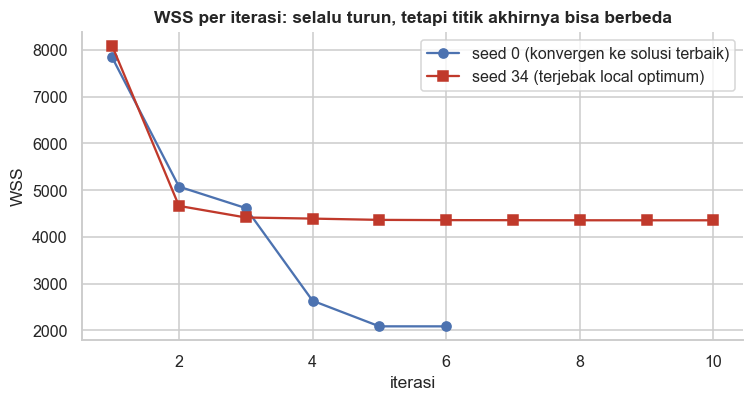

In [91]:
hist_buruk = fc.lloyd_kmeans(X2, titik_awal(34))
tab_buruk = pd.DataFrame([{c: h[c] for c in ("iterasi", "pindah", "wss")} for h in hist_buruk]).set_index("iterasi")
display(tab_buruk)
print("Ukuran cluster solusi buruk :", np.bincount(hist_buruk[-1]["label"]).tolist(), f"| WSS final = {hist_buruk[-1]['wss']:,.1f}")
print("Ukuran cluster solusi baik  :", np.bincount(hist_baik[-1]["label"]).tolist(), f"| WSS final = {hist_baik[-1]['wss']:,.1f}")
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(tab_baik.index, tab_baik["wss"], "o-", label="seed 0 (konvergen ke solusi terbaik)")
ax.plot(tab_buruk.index, tab_buruk["wss"], "s-", color="#c0392b", label="seed 34 (terjebak local optimum)")
ax.set_xlabel("iterasi"); ax.set_ylabel("WSS"); ax.set_title("WSS per iterasi: selalu turun, tetapi titik akhirnya bisa berbeda"); ax.legend()
plt.tight_layout(); fc.save_fig(fig, "05c_kmeans_wss_iterasi"); plt.show()

**Hasil & interpretasi:** dari seed 34, algoritma juga konvergen (10 iterasi, `pindah` = 0), tetapi berhenti di **WSS 4.355,7**, hampir **dua kali lipat** solusi terbaik (2.087,5), dengan ukuran cluster yang janggal (146 / 105 / 591 / 150: dua kelompok digabung dan satu kelompok dipecah). Kedua kurva WSS turun monoton; *konvergen tidak berarti optimal*.

### 4c. Solusi: banyak titik awal (`n_init`) dan k-means++
Dua penangkal:
- **`n_init`:** algoritma dijalankan berulang dari titik awal berbeda; hanya hasil dengan **WSS terkecil** yang disimpan.
- **k-means++:** cara memilih titik awal yang **menyebar** (centroid berikutnya dipilih dengan peluang lebih besar bila jauh dari centroid yang sudah ada). Ini bawaan scikit-learn.

Kita ukur seberapa sering satu kali jalan (tanpa pengulangan) mencapai solusi terbaik: 30 percobaan untuk titik awal acak murni dan 30 untuk k-means++.

In [92]:
res_rand = [KMeans(4, init="random",    n_init=1, random_state=s).fit(X2).inertia_ for s in range(30)]
res_pp   = [KMeans(4, init="k-means++", n_init=1, random_state=s).fit(X2).inertia_ for s in range(30)]
best = min(res_rand + res_pp)

tab_init = pd.DataFrame({
    "mencapai WSS terbaik (dari 30)": [sum(abs(v - best) < 0.5 for v in res_rand), sum(abs(v - best) < 0.5 for v in res_pp)],
    "WSS terbaik":  [min(res_rand), min(res_pp)],
    "WSS terburuk": [max(res_rand), max(res_pp)],
}, index=["titik awal acak murni", "k-means++"])
display(tab_init.style.format({"mencapai WSS terbaik (dari 30)": "{:.0f}", "WSS terbaik": "{:,.1f}", "WSS terburuk": "{:,.1f}"}))

# Sebaran lengkap: tiap nilai WSS muncul berapa kali (bukti bahwa hasil terbaik memang yang paling sering)
for nama, res in [("acak murni", res_rand), ("k-means++", res_pp)]:
    sebaran = pd.Series([round(v, 1) for v in res]).value_counts().sort_index()
    print(f"\nSebaran WSS ({nama}): nilai -> berapa kali muncul")
    print(sebaran.to_string())

,mencapai WSS terbaik (dari 30),WSS terbaik,WSS terburuk
titik awal acak murni,16,"2,087.5","4,355.5"
k-means++,24,"2,087.5","2,704.1"



Sebaran WSS (acak murni): nilai -> berapa kali muncul
2,087.500    16
2,671.400     1
2,671.800     1
2,672.000     1
2,674.000     2
2,704.100     3
2,704.800     1
2,706.000     1
2,717.100     1
2,746.100     1
4,355.500     2

Sebaran WSS (k-means++): nilai -> berapa kali muncul
2,087.500    24
2,671.400     2
2,672.000     1
2,704.100     3


**Hasil & interpretasi:** dengan titik awal acak murni hanya 16 dari 30 percobaan mencapai WSS terbaik (2.087,5); sisanya tersebar di 10 nilai berbeda antara 2.671 dan 2.746, dan 2 percobaan bahkan di 4.355. Dengan k-means++ sebanyak 24 dari 30 mencapai solusi terbaik, dan sisanya hanya tiga nilai (2.671–2.704). Nilai terbaik (2.087,5) sama untuk kedua metode, jadi k-means++ tidak menemukan solusi yang lebih baik, hanya lebih sering menemukannya dan tidak pernah terjebak di 4.355. Karena itu solusi final memakai k-means++ dan n_init = 30 (30 kali jalan, ambil yang terbaik).

In [93]:
km = KMeans(K, n_init=30, random_state=RANDOM_STATE).fit(X2)
lab_k_raw = km.labels_
print(f"WSS final (inertia) = {km.inertia_:,.1f} | iterasi pada run terbaik = {km.n_iter_}")
# Cek: solusi demonstrasi manual (seed 0) harus sama dengan hasil scikit-learn
print("ARI antara demonstrasi manual (seed 0) dan scikit-learn:", round(adjusted_rand_score(hist_baik[-1]["label"], lab_k_raw), 4))
print("Ukuran cluster K-means (A2), label mentah:"); fc.size_table(lab_k_raw)

WSS final (inertia) = 2,087.5 | iterasi pada run terbaik = 7
ARI antara demonstrasi manual (seed 0) dan scikit-learn: 1.0
Ukuran cluster K-means (A2), label mentah:


,n,persen
0,150,15.121
1,297,29.940
2,297,29.940
3,248,25.000


**Hasil & interpretasi:** WSS final = **2.087,5**, persis sama dengan solusi terbaik dari demonstrasi manual (ARI = 1,00 → partisi yang sama; yang berbeda hanya penomoran label). Ukuran cluster menurut label mentah: 150 / 297 / 297 / 248 (urutannya acak; akan dicocokkan ke label Ward di Step 5). (`n_iter_` scikit-learn menghitung putaran sedikit berbeda dari tabel manual, jadi angka iterasinya bisa tidak sama.)

### 4d. Memastikan k = 4 juga masuk akal di A2
Indikator yang sama dihitung ulang di A2 sebagai pemeriksaan independen.

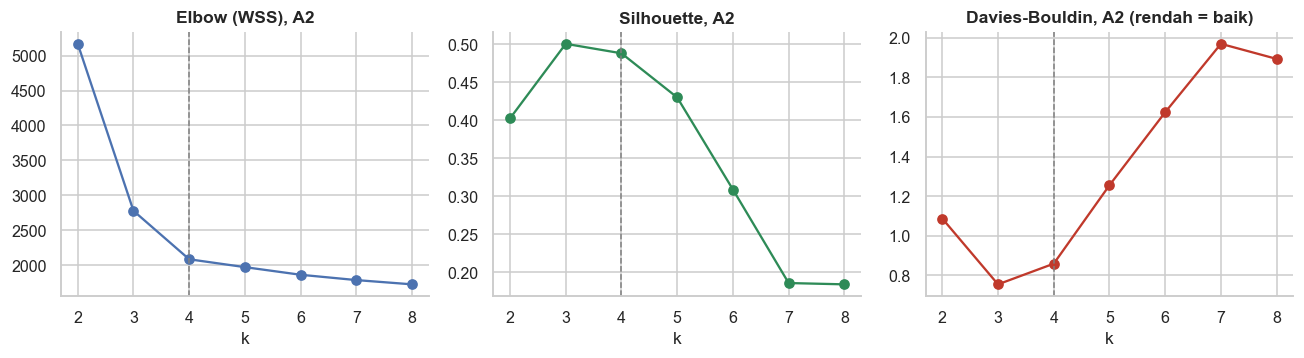

,silhouette,calinski_harabasz,davies_bouldin,wss,cluster_terkecil_pct
k,,,,,
2,0.402,720.443,1.087,"5,167.503",40.222
3,0.501,"1,093.344",0.755,"2,780.434",29.940
4,0.488,"1,079.157",0.859,"2,087.545",15.121
5,0.430,868.571,1.255,"1,975.202",9.778
6,0.309,746.221,1.624,"1,866.189",9.677
7,0.186,654.598,1.970,"1,790.112",10.585
8,0.184,585.179,1.893,"1,729.274",8.266


In [94]:
ev_k = fc.evaluate_k(Z2, ks=range(2, 9), method="kmeans", random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].plot(ev_k.index, ev_k["wss"], "o-"); axes[0].set_title("Elbow (WSS), A2")
axes[1].plot(ev_k.index, ev_k["silhouette"], "o-", color="#2e8b57"); axes[1].set_title("Silhouette, A2")
axes[2].plot(ev_k.index, ev_k["davies_bouldin"], "o-", color="#c0392b"); axes[2].set_title("Davies-Bouldin, A2 (rendah = baik)")
for ax in axes: ax.axvline(4, color="grey", ls="--", lw=1); ax.set_xlabel("k")
plt.tight_layout(); plt.show()
ev_k

**Hasil & interpretasi:** polanya **sama dengan A1**: k = 3 (silhouette 0,501) dan k = 4 (0,488) sama-sama tinggi, lalu anjlok pada k = 5 (0,430) dan k = 6 (0,309). Davies-Bouldin juga memburuk tajam setelah k = 4 (0,859 → 1,255). Jadi pemilihan k = 4 bukan artefak sampel A1.

### Rangkuman Step 4
- K-means pada A2 memakai spesifikasi identik dengan A1 dan **k = 4**.
- **Mekanisme:** centroid awal → tugaskan tiap member ke centroid terdekat → pindahkan centroid ke rata-rata anggota → ulangi sampai tidak ada yang pindah. WSS turun monoton (7.838 → 2.087,5 pada demonstrasi).
- **Jebakan local optimum:** dari titik awal buruk, WSS berhenti di 4.355,7 (dua kali lebih buruk); titik awal acak murni hanya 16/30 mencapai solusi terbaik, k-means++ 24/30. Solusi final memakai k-means++ + `n_init = 30` + `random_state = 42`.
- **Hasil di A2:** WSS final 2.087,5, ukuran cluster 150 / 248 / 297 / 297; indikator pemilihan k di A2 mengulang pola A1 (k = 3 dan 4 sama-sama baik, k ≥ 5 memburuk).

---
# Step 5. Perbandingan Hierarkis (A1) vs K-means (A2), Stabilitas, dan Respesifikasi  *(Langkah 4 assignment)*

### Tujuan
Menilai apakah solusi 4 segmen **konsisten dan stabil**; bila tidak, menelusuri penyebabnya dan melakukan respesifikasi.

### Logika
Kita memakai **lima bukti yang saling melengkapi**, karena satu bukti saja bisa menipu:

| Bukti | Pertanyaan yang dijawab | Kelemahan bila berdiri sendiri |
|---|---|---|
| 1. Ukuran cluster | apakah proporsinya sama? | ukuran bisa sama padahal isi berbeda |
| 2. Selisih centroid | apakah rata-rata profilnya sama? | rata-rata sama belum tentu orangnya sama |
| 3. Penempatan silang + ARI | apakah member yang sama masuk kelompok yang sama? | hanya menguji dua solusi |
| 4. Bootstrap | apakah solusi stabil bila datanya diubah sedikit? | tidak membandingkan A1 dan A2 |
| 5. Uji spesifikasi | di mana letak masalah bila tidak konsisten? | – |

### 5a. Mencocokkan label cluster
**Masalah:** nomor cluster hanya label acak (cluster "0" di K-means belum tentu cluster "0" di Ward). Sebelum dibandingkan, label K-means harus dipasangkan ke label Ward.

**Mekanisme (Hungarian algorithm):** hitung **jarak antara setiap centroid K-means dan setiap centroid Ward** (matriks 4×4), lalu cari **pasangan 1-ke-1 dengan total jarak terkecil**. Ini lebih baik daripada "ambil yang terdekat untuk tiap cluster" karena mencegah dua cluster K-means mengklaim satu cluster Ward yang sama.

In [95]:
cent_h = fc.cluster_centroids(Z1, lab_h)            # centroid Ward (A1), satuan z-score
cent_k = fc.cluster_centroids(Z2, lab_k_raw)        # centroid K-means (A2), label mentah
jarak = np.linalg.norm(cent_k.values[:, None, :] - cent_h.values[None, :, :], axis=2)
display(pd.DataFrame(jarak, index=[f"K-means {i}" for i in cent_k.index],
                     columns=[f"Ward {j}" for j in cent_h.index]).style.format("{:.2f}")
        .set_caption("Jarak Euclidean antara centroid K-means (baris) dan Ward (kolom)"))
mapping = {int(a): int(b) for a, b in fc.match_clusters(cent_h, cent_k).items()}
print("Pemetaan label K-means -> Ward:", mapping)
lab_k = pd.Series(lab_k_raw).map(mapping).values
a2["cl_kmeans"] = lab_k

,Ward 0,Ward 1,Ward 2,Ward 3
K-means 0,0.09,2.71,4.52,4.11
K-means 1,4.07,5.42,4.05,0.06
K-means 2,4.49,4.16,0.05,4.03
K-means 3,2.71,0.09,4.13,5.47


Pemetaan label K-means -> Ward: {0: 0, 1: 3, 2: 2, 3: 1}


**Hasil & interpretasi:** setiap baris matriks memiliki **satu nilai sangat kecil (0,05–0,09)** dan nilai lain **2,7 atau lebih**. Artinya tiap cluster K-means memiliki "kembaran" yang jelas di Ward, dan pemasangannya tidak ambigu. Jarak ke cluster yang salah paling kecil 2,71 (itu pasangan cluster 0 dan 1, yaitu dua kelompok liburan yang paling berdekatan).

### 5b. Bukti 1: ukuran cluster

In [96]:
sz = pd.concat([fc.size_table(lab_h).add_prefix("A1 Ward_"), fc.size_table(lab_k).add_prefix("A2 KMeans_")], axis=1)
sz

,A1 Ward_n,A1 Ward_persen,A2 KMeans_n,A2 KMeans_persen
0,150,15.136,150,15.121
1,249,25.126,248,25.000
2,296,29.869,297,29.940
3,296,29.869,297,29.940


**Hasil:** selisih ukuran paling banyak **1 member** (A1: 150 / 249 / 296 / 296; A2: 150 / 248 / 297 / 297). Proporsinya identik sampai satu desimal persen.

### 5c. Bukti 2: selisih centroid
**Mekanisme:** bandingkan rata-rata z-score tiap cluster di A1 vs A2 untuk setiap variabel (4 cluster × 9 variabel = 36 sel). Ada dua cara meringkas:
- **Selisih per variabel (maksimum dari 36 sel):** mudah dijelaskan.
- **Jarak Euclidean antar centroid** (menggabungkan 9 variabel). Dua angka ini **berbeda skala**: jarak Euclidean menjumlahkan kuadrat semua selisih, jadi bisa lebih besar dari selisih terbesar pada satu variabel (mis. 9 variabel masing-masing meleset 0,03 → selisih terbesar 0,03 tetapi jarak 0,09). Pembanding harus **sejenis**.

**Pembanding yang tepat:** "kecil" harus dinilai terhadap perbedaan antar-segmen yang *sebenarnya*. Maka kita hitung juga jarak antar-centroid segmen **yang berbeda** dalam satu dataset.

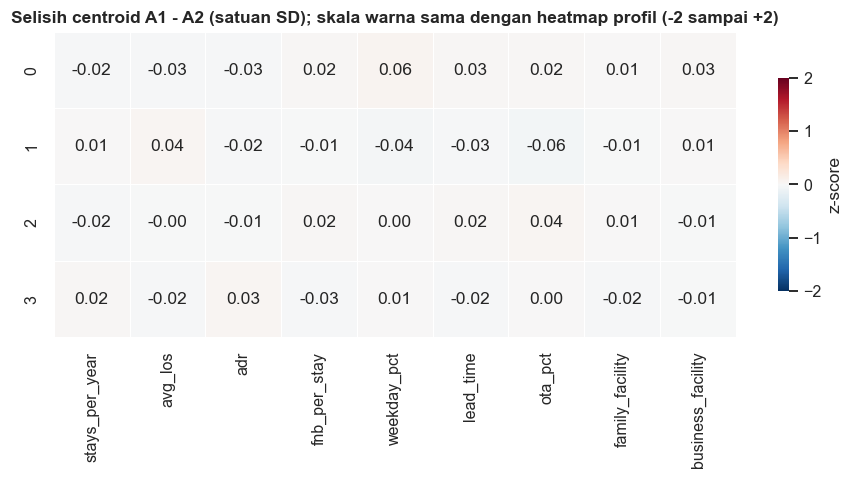

Sel dengan selisih terbesar:
  cluster 1 | ota_pct          A1 = +0.053  A2 = +0.113  selisih = -0.060
  cluster 0 | weekday_pct      A1 = -0.429  A2 = -0.489  selisih = +0.060
  cluster 1 | avg_los          A1 = +1.097  A2 = +1.057  selisih = +0.039
  cluster 2 | ota_pct          A1 = +1.278  A2 = +1.239  selisih = +0.039

Selisih per-variabel: maks = 0.060 SD, rata-rata = 0.021 SD
Jarak Euclidean cluster YANG SAMA, A1 vs A2      : [0.089 0.09  0.053 0.058]
Jarak Euclidean antar-segmen BERBEDA (A1), 6 pasangan: [2.7  4.5  4.09 4.15 5.46 4.06]
Rasio (jarak antar-segmen terkecil / jarak A1-A2 terbesar) = 30x


In [97]:
cent_k_m = fc.cluster_centroids(Z2, lab_k)
selisih = cent_h - cent_k_m                          # A1 dikurangi A2
fig, ax = plt.subplots(figsize=(10, 3.6))
fc.plot_profile_heatmap(selisih, ax=ax, title="Selisih centroid A1 - A2 (satuan SD); skala warna sama dengan heatmap profil (-2 sampai +2)")
fc.save_fig(fig, "06b_selisih_centroid"); plt.show()
top = selisih.abs().stack().sort_values(ascending=False).head(4)
print("Sel dengan selisih terbesar:")
for (c, v), x in top.items():
    print(f"  cluster {c} | {v:16s} A1 = {cent_h.loc[c, v]:+.3f}  A2 = {cent_k_m.loc[c, v]:+.3f}  selisih = {cent_h.loc[c, v] - cent_k_m.loc[c, v]:+.3f}")
d_sama = np.linalg.norm(cent_h.values - cent_k_m.values, axis=1)
d_antar = pd.DataFrame(squareform(pdist(cent_h.values)), index=cent_h.index, columns=cent_h.index)
iu = np.triu_indices(4, 1)
print(f"\nSelisih per-variabel: maks = {selisih.abs().values.max():.3f} SD, rata-rata = {selisih.abs().values.mean():.3f} SD")
print("Jarak Euclidean cluster YANG SAMA, A1 vs A2      :", np.round(d_sama, 3))
print("Jarak Euclidean antar-segmen BERBEDA (A1), 6 pasangan:", np.round(d_antar.values[iu], 2))
print(f"Rasio (jarak antar-segmen terkecil / jarak A1-A2 terbesar) = {d_antar.values[iu].min() / d_sama.max():.0f}x")

**Hasil & interpretasi:**
- Selisih per variabel maksimum **0,06 SD**, muncul di **dua sel kembar**: `ota_pct` cluster 1 (A1 = 0,053 vs A2 = 0,113) dan `weekday_pct` cluster 0 (−0,429 vs −0,489). Rata-rata seluruh selisih hanya **0,02 SD**. Selisih terbesar tidak terkumpul pada satu variabel atau satu cluster, sehingga lebih mirip fluktuasi acak daripada perbedaan sistematis.
- Jarak Euclidean cluster yang sama antara A1 dan A2 hanya **0,05–0,09**, sedangkan jarak antar-segmen yang berbeda **2,7–5,5**. Segmen yang berbeda **±30 kali atau lebih** lebih jauh satu sama lain daripada dua versi segmen yang sama. Untuk skala: simpangan baku di dalam satu cluster rata-rata sekitar 0,46.
- **Keterbatasan:** selisih centroid kecil adalah syarat perlu, bukan syarat cukup (dua cluster bisa punya rata-rata sama dengan komposisi orang berbeda). Itu sebabnya bukti 3 diperlukan.

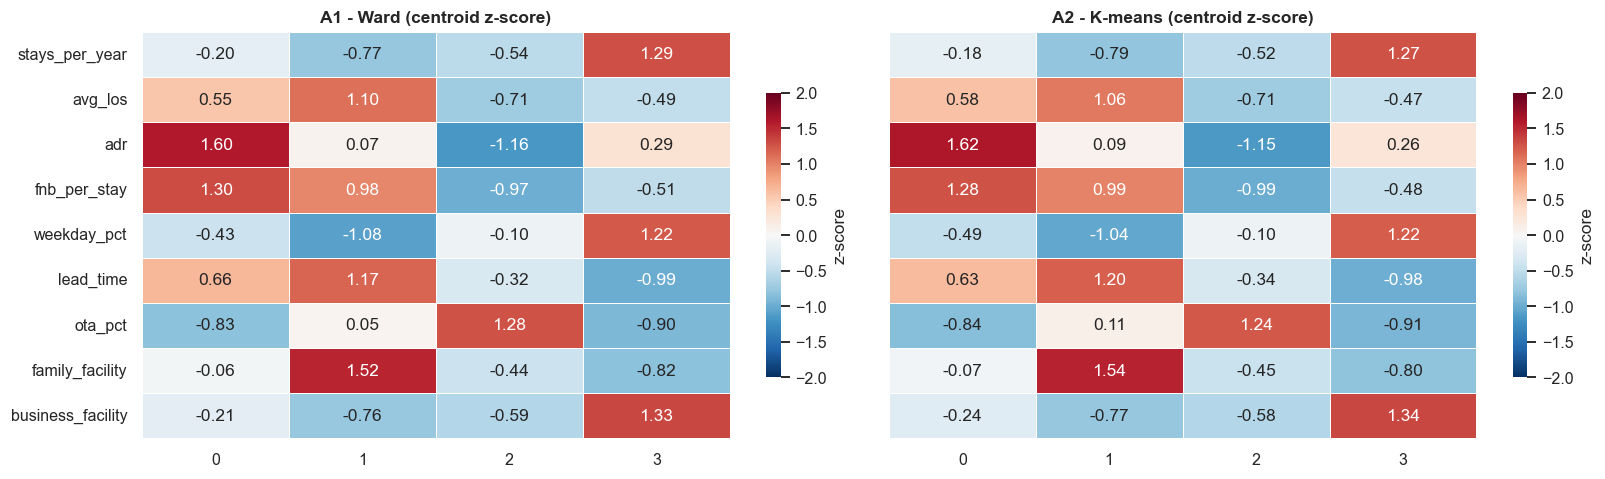

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
fc.plot_profile_heatmap(cent_h.T, ax=axes[0], title="A1 - Ward (centroid z-score)")
fc.plot_profile_heatmap(cent_k_m.T, ax=axes[1], title="A2 - K-means (centroid z-score)")
plt.tight_layout(); fc.save_fig(fig, "06_centroid_A1_vs_A2"); plt.show()

# Dalam satuan ASLI (median), agar terasa nyata, bukan hanya z-score
key = ["stays_per_year", "adr", "ota_pct", "weekday_pct"]
raw_cmp = pd.concat({"A1 (Ward)": a1.groupby("cl_hier")[key].median(),
                     "A2 (K-means)": a2.groupby("cl_kmeans")[key].median()}, axis=1)
raw_cmp.style.format("{:,.1f}")

**Hasil:** dua heatmap hampir tidak bisa dibedakan secara visual. Dalam satuan asli (median), contoh cluster 3: **12,5 vs 12** stay/tahun, 86,6% vs 86,7% malam hari kerja; cluster 0: ADR **Rp3,20 juta vs Rp3,31 juta**; cluster 2: OTA **77,7% vs 76,5%**. Perbedaan sekecil ini tidak mengubah makna bisnis segmen mana pun.

### 5d. Bukti 3: penempatan silang dan ARI
**Mekanisme – penempatan silang:**
1. Ambil 992 member A2, standarisasi dengan **rata-rata dan simpangan baku A1** (bukan A2), sehingga skalanya sama.
2. Tempatkan tiap member A2 ke **centroid A1 terdekat** ("tebakan A1").
3. Bandingkan dengan **label K-means A2 sendiri**. Bila segmen A1 dan A2 sama, kedua cara memberi label harus cocok.

**Mekanisme – ARI (Adjusted Rand Index):** membandingkan dua pengelompokan lewat **semua pasangan member**: apakah sepasang member sama-sama dikelompokkan bersama (atau sama-sama dipisah) di kedua solusi? Hasilnya dikoreksi terhadap peluang kebetulan. **1 = identik, 0 = setara tebakan acak.** Kelebihan dibanding "persen kesesuaian": ARI tidak terpengaruh penomoran label. Contoh mini:

In [99]:
a = [0, 0, 0, 1, 1, 1, 2, 2, 2]
print("Label sama persis, hanya nomor ditukar        :", adjusted_rand_score([0, 0, 1, 1, 2, 2], [1, 1, 0, 0, 2, 2]))
print("Dua dari sembilan orang berpindah kelompok     :", round(adjusted_rand_score(a, [0, 0, 1, 1, 1, 1, 2, 2, 0]), 3))
rng = np.random.default_rng(0)
print("Dua pengelompokan acak independen (n = 2.000)  :", round(adjusted_rand_score(rng.integers(0, 4, 2000), rng.integers(0, 4, 2000)), 4))

Label sama persis, hanya nomor ditukar        : 1.0
Dua dari sembilan orang berpindah kelompok     : 0.357
Dua pengelompokan acak independen (n = 2.000)  : -0.0001


**Hasil:** menukar nomor label tidak mengubah ARI (tetap 1,0); memindahkan 2 dari 9 orang menurunkannya menjadi 0,357; dua pengelompokan acak mendekati 0. Jadi ARI = 1,00 berarti benar-benar partisi yang sama.

In [100]:
Z2_on_1, _ = fc.prepare_features(a2, FINAL_VARS, LOG_FINAL, scaler=scaler1)      # A2 dengan skala A1
pred_a2 = fc.assign_to_centroids(Z2_on_1, cent_h)
ari_cross = adjusted_rand_score(a2["cl_kmeans"], pred_a2)
agree = (a2["cl_kmeans"].values == pred_a2).mean() * 100
print(f"ARI (K-means A2 vs penempatan ke centroid A1) = {ari_cross:.3f}")
print(f"Kesesuaian penempatan                         = {agree:.1f}%")
pd.crosstab(a2["cl_kmeans"], pred_a2, rownames=["label K-means A2"], colnames=["tebakan dari centroid A1"])

ARI (K-means A2 vs penempatan ke centroid A1) = 1.000
Kesesuaian penempatan                         = 100.0%


tebakan dari centroid A1,0,1,2,3
label K-means A2,,,,
0,150,0,0,0
1,0,248,0,0
2,0,0,297,0
3,0,0,0,297


**Hasil & interpretasi:** semua 992 member A2 ditempatkan ke cluster yang **sama** oleh dua cara berbeda: kesesuaian **100%**, ARI **1,00**; tabel silang hanya terisi di diagonal. Karena centroid A1 (dari algoritma Ward pada sampel lain) dapat "menebak" label K-means A2 tanpa satu pun salah, segmen A1 dan A2 adalah kelompok orang yang sama.

### 5e. Bukti 4: stabilitas bootstrap
**Mekanisme:** ambil acak **80%** member A2, jalankan K-means ulang, bandingkan hasilnya dengan solusi utama pada member yang sama (ARI). Diulang **100 kali**. Bila ARI selalu mendekati 1, solusi tidak berubah walau datanya dikurangi 20% secara acak.

In [101]:
aris = fc.bootstrap_stability(Z2, K, n_boot=100, frac=0.8, random_state=RANDOM_STATE)
print(f"ARI bootstrap: rata-rata = {aris.mean():.3f}, minimum = {aris.min():.3f}, maksimum = {aris.max():.3f}  (100 resample, 80% data)")

ARI bootstrap: rata-rata = 1.000, minimum = 1.000, maksimum = 1.000  (100 resample, 80% data)


**Hasil:** ARI rata-rata, minimum, dan maksimum semuanya **1,000** → pada 100 dari 100 pengulangan, partisi tidak berubah sama sekali. Solusi 4 segmen sangat stabil terhadap perubahan sampel.

### 5f. Bukti 5: respesifikasi, menelusuri penyebab bila tidak konsisten
**Mekanisme:** soal meminta, bila hasil tidak konsisten, menelusuri penyebabnya dan merespesifikasi. Kita **mereplikasi proses itu**: menjalankan alur yang sama dengan empat spesifikasi bertahap, dan melihat di mana masalah muncul dan hilang. Spesifikasi dideklarasikan eksplisit di bawah.

| # | Spesifikasi | Perlakuan |
|---|---|---|
| 1 | Naif | data **mentah** (belum dibersihkan), 16 variabel, tanpa log |
| 2 | + pembersihan | data bersih, 16 variabel, tanpa log |
| 3 | + log | data bersih, 16 variabel, log pada 12 variabel miring |
| 4 | **Final** | data bersih, **9 variabel**, log pada 7 |

In [102]:
spesifikasi = {
    "1. Naif: mentah, 16 var, tanpa log":  fc.run_spec(a1_raw, a2_raw, BEHAVIOR_VARS, [], k=4),
    "2. + bersih, 16 var, tanpa log":      fc.run_spec(a1, a2, BEHAVIOR_VARS, [], k=4),
    "3. + log, 16 var":                    fc.run_spec(a1, a2, BEHAVIOR_VARS, LOG_ALL, k=4),
    "4. FINAL: bersih, 9 var, + log":      fc.run_spec(a1, a2, FINAL_VARS, LOG_FINAL, k=4),
}
cmp_spec = pd.DataFrame(spesifikasi).T
cmp_spec

,ukuran A1 (Ward),ukuran A2 (K-means),silhouette A1,silhouette A2,ARI (A2 K-means vs centroid A1),cluster terkecil (A1)
"1. Naif: mentah, 16 var, tanpa log","[691, 298, 10, 1]","[579, 416, 4, 1]",0.381,0.380,0.698,1
"2. + bersih, 16 var, tanpa log","[399, 296, 293, 3]","[381, 308, 300, 3]",0.418,0.400,0.991,3
"3. + log, 16 var","[296, 296, 249, 150]","[297, 297, 247, 151]",0.479,0.470,1.000,150
"4. FINAL: bersih, 9 var, + log","[296, 296, 249, 150]","[297, 297, 248, 150]",0.497,0.488,1.000,150


**Hasil & interpretasi (baris demi baris):**
- **Baris 1 (naif) = kasus "tidak konsisten".** Ukuran A1 = [691, 298, **10, 1**]: dua dari empat "segmen" hanyalah 10 dan 1 orang; ARI hanya **0,698**. Penyebab: outlier dan placeholder yang tidak dibersihkan disisihkan algoritma sebagai cluster tersendiri, dan karena anomali di A1 dan A2 berbeda orang, hasil dua sampel ikut berbeda.
- **Baris 2 (+ pembersihan):** ARI naik ke **0,991**, tetapi masih ada cluster berisi **3 orang**. Pelajaran: **konsisten belum tentu berguna**; dua sampel sama-sama menemukan "cluster 3 orang", itu konsisten tetapi tak bisa jadi segmen marketing.
- **Baris 3 (+ log):** ukuran cluster menjadi sehat [296, 296, 249, 150], silhouette 0,479, ARI **1,000**. Inilah lompatan terbesar.
- **Baris 4 (final, 9 variabel):** ukuran hampir sama dengan baris 3, silhouette naik sedikit (0,479 → **0,497**). Jujur: **seleksi variabel tidak "menyelamatkan" hasil**; manfaatnya lebih pada kesahihan konsep (tidak menghitung belanja berkali-kali) dan kemudahan interpretasi.
- Urutan kontribusi: **pembersihan dan log paling berpengaruh; seleksi variabel memperhalus.**

In [103]:
# Apakah k lain juga konsisten? (spesifikasi final)
cmp_k = pd.DataFrame({f"k = {k}": fc.run_spec(a1, a2, FINAL_VARS, LOG_FINAL, k=k) for k in (3, 4, 5)}).T
cmp_k

,ukuran A1 (Ward),ukuran A2 (K-means),silhouette A1,silhouette A2,ARI (A2 K-means vs centroid A1),cluster terkecil (A1)
k = 3,"[399, 296, 296]","[398, 297, 297]",0.509,0.501,1.000,296
k = 4,"[296, 296, 249, 150]","[297, 297, 248, 150]",0.497,0.488,1.000,150
k = 5,"[296, 249, 150, 150, 146]","[297, 297, 151, 150, 97]",0.361,0.430,0.787,146


**Hasil & interpretasi:** pada **k = 5** ARI turun ke **0,787** dan silhouette ke 0,36. Dari ukurannya terlihat A1 memecah cluster besar menjadi 150 + 146, sedangkan A2 memecah cluster lain menjadi 151 + 97; dua sampel memecah di tempat berbeda, tanda bahwa cluster kelima **tidak reproduktif**. **Catatan jujur:** k = 3 juga konsisten (ARI 1,00), jadi uji ini hanya menyingkirkan k ≥ 5; pilihan 3 vs 4 tetap bertumpu pada alasan di Step 3.

### Rangkuman Step 5
| Bukti | Hasil |
|---|---|
| Ukuran cluster | A1 [150, 249, 296, 296] vs A2 [150, 248, 297, 297], selisih ≤ 1 member |
| Selisih centroid | maks 0,06 SD per variabel (rata-rata 0,02); jarak Euclidean 0,05–0,09 vs 2,7–5,5 antar-segmen |
| Penempatan silang | kesesuaian 100%, ARI = 1,00 |
| Bootstrap (100×, 80% data) | ARI = 1,000 (min = maks) |
| Spesifikasi naif | gagal: cluster 1 dan 10 orang, ARI 0,698 → diperbaiki lewat pembersihan, log, seleksi variabel |
| k = 5 | tidak reproduktif (ARI 0,787) |

**Kesimpulan:** solusi 4 segmen **reproduktif** pada dua sampel independen dan dua algoritma berbeda, jadi tidak diperlukan respesifikasi lebih lanjut. Respesifikasi yang sudah dilakukan (pembersihan → log → seleksi variabel) adalah yang menyelesaikan masalah pada spesifikasi naif.

---
# Step 6. Profiling Segmen  *(Langkah 5 assignment)*

### Tujuan
Mengetahui segmen itu **siapa** dan variabel mana yang **benar-benar membedakan** segmen, dengan uji statistik yang sesuai: perilaku dulu, lalu demografi dan sosial ekonomi.

### Keputusan penggabungan data
A1 (label Ward) dan A2 (label K-means yang sudah dicocokkan) digabung → **n = 1.983**. Karena Step 5 membuktikan kedua solusi konsisten, penggabungan ini aman, dan sampel lebih besar membuat uji lebih kuat.

### Tentang penamaan
Di step ini segmen masih dirujuk dengan **nomor** (0–3). Nama segmen baru diberikan di **Step 7**, setelah kita membaca profilnya; dengan begitu nama itu terlihat berasal dari data, bukan muncul tiba-tiba.

In [104]:
a1["seg_id"], a2["seg_id"] = a1["cl_hier"], a2["cl_kmeans"]
pool = pd.concat([a1, a2], ignore_index=True)
ID_COLORS = {0: "#4c72b0", 1: "#dd8452", 2: "#55a868", 3: "#c44e52"}
print("Total member (gabungan):", len(pool))
fc.size_table(pool["seg_id"])

Total member (gabungan): 1983


,n,persen
seg_id,,
0,300,15.129
1,497,25.063
2,593,29.904
3,593,29.904


**Hasil:** 1.983 member; ukuran segmen 0 = 300 (15,1%), 1 = 497 (25,1%), 2 = 593 (29,9%), 3 = 593 (29,9%).

### 6a. Profil perilaku
**Mekanisme:** rata-rata tiap variabel perilaku per segmen (satuan asli, mudah dibaca) dan **z-score profil** = rata-rata variabel tiap segmen dikurangi rata-rata seluruh member, dibagi simpangan baku seluruh member. Z-score profil dihitung dari **nilai asli** (bukan log) agar tafsirannya langsung: +1 = "1 simpangan baku di atas rata-rata seluruh member". Heatmap merah = di atas rata-rata, biru = di bawah.

,0,1,2,3
stays_per_year,4.36,2.60,3.24,14.43
total_nights,12.72,9.28,5.41,26.05
avg_los,2.93,3.61,1.66,1.86
adr,"3,744,123.33","1,350,623.74","630,669.48","1,523,942.66"
room_spend,"50,851,896.67","12,502,869.22","3,415,431.70","40,162,753.79"
fnb_per_stay,"2,376,363.33","1,503,768.61","158,116.36","272,596.96"
spa_per_stay,"1,508,440.00","409,402.41","16,957.84","46,337.27"
total_spend,"69,778,803.33","17,407,400.40","3,985,197.30","44,704,320.40"
weekday_pct,41.02,25.36,50.44,84.75
lead_time,30.81,48.86,15.37,7.60


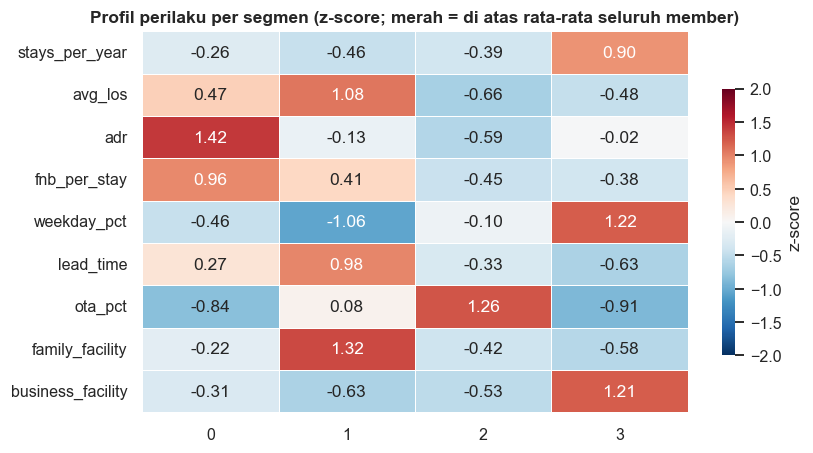

In [105]:
means_beh = fc.cluster_means(pool, pool["seg_id"], BEHAVIOR_VARS)
display(means_beh.T.style.format("{:,.2f}"))
zprof = fc.zscore_profile(pool, pool["seg_id"], FINAL_VARS)
fig, ax = plt.subplots(figsize=(8, 4.5))
fc.plot_profile_heatmap(zprof.T, ax=ax, title="Profil perilaku per segmen (z-score; merah = di atas rata-rata seluruh member)")
fc.save_fig(fig, "07a_profil_perilaku_id"); plt.show()

**Hasil & interpretasi:** empat profil yang sangat berbeda:
- **Segmen 3:** stay paling sering (14,4/tahun), 85% malam hari kerja, lead time pendek (7,6 hari), OTA hanya 10%, fasilitas bisnis tertinggi.
- **Segmen 0:** ADR paling tinggi (Rp3,74 juta) dan belanja F&B/spa terbesar, tetapi hanya 4,4 stay/tahun; lebih banyak akhir pekan (hari kerja 41%).
- **Segmen 1:** fasilitas keluarga tertinggi, menginap terlama (3,6 malam), mayoritas akhir pekan (hari kerja 25%), lead time paling panjang (49 hari), OTA 40%.
- **Segmen 2:** OTA 76%, ADR terendah (Rp0,63 juta), jarang membuka aplikasi (2,2 sesi/bulan).

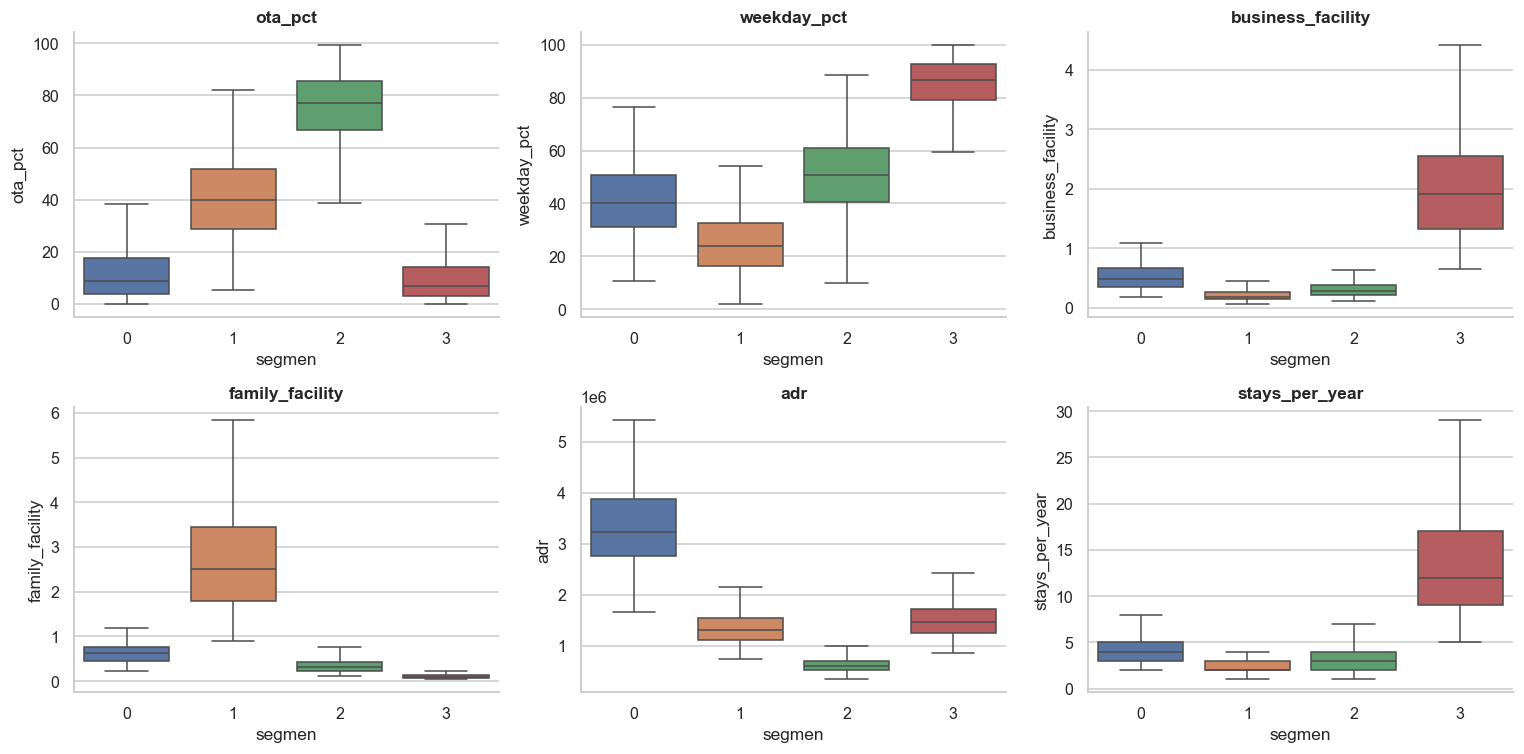

In [106]:
# Sebaran per segmen untuk 6 variabel pembeda utama (boxplot; titik ekstrem disembunyikan agar kotak terbaca)
var_plot = ["ota_pct", "weekday_pct", "business_facility", "family_facility", "adr", "stays_per_year"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, v in zip(axes.ravel(), var_plot):
    sns.boxplot(data=pool, x="seg_id", y=v, order=[0, 1, 2, 3], palette=[ID_COLORS[i] for i in range(4)], showfliers=False, ax=ax)
    ax.set_title(v); ax.set_xlabel("segmen")
plt.tight_layout(); fc.save_fig(fig, "07b_boxplot_perilaku_id"); plt.show()

**Hasil & interpretasi:** boxplot memperlihatkan hal yang tidak terlihat dari rata-rata, yaitu **tidak ada satu variabel pun yang memisahkan keempat segmen sekaligus**. Tiap segmen "terisolasi" oleh variabel yang berbeda:
- `ota_pct`: segmen 2 (tinggi) dan 1 (menengah) terpisah jelas, tetapi segmen 0 dan 3 **tumpang tindih** (keduanya rendah).
- `weekday_pct`: segmen 3 (tinggi) dan 1 (rendah) terpisah; segmen 0 dan 2 saling tumpang tindih.
- `business_facility` dan `stays_per_year`: hanya segmen 3 yang menonjol; `family_facility`: hanya segmen 1; `adr`: segmen 0 jauh di atas dan segmen 2 terendah, sedangkan segmen 1 dan 3 tumpang tindih.

Artinya segmen terbentuk dari **kombinasi** variabel, bukan dari satu variabel tunggal. Ini juga menjelaskan mengapa Ward/K-means (yang melihat semua variabel sekaligus) lebih tepat daripada sekadar memotong satu variabel. Pola ini konsisten dengan urutan kekuatan pembeda pada tabel uji di bawah.

### 6b. Uji statistik: penjelasan mekanisme

**Mengapa perlu uji?** Rata-rata yang berbeda belum tentu berarti perbedaan yang nyata. Uji statistik memisahkan **perbedaan sungguhan** dari **fluktuasi kebetulan**.

**ANOVA satu arah (variabel numerik).** Membandingkan *variasi antar-segmen* dengan *variasi di dalam segmen*:
- `SS_antar` = Σ (jumlah anggota × (rata-rata segmen − rata-rata total)²) → seberapa jauh rata-rata segmen menyimpang.
- `SS_dalam` = total variasi − `SS_antar` → sebaran individu di dalam segmen.
- **F = (SS_antar / df_antar) ÷ (SS_dalam / df_dalam)**, dengan df_antar = jumlah segmen − 1 = 3 dan df_dalam = n − jumlah segmen = 1.979. F besar → perbedaan antar-segmen jauh melebihi variasi acak.
- **η² (eta-squared) = SS_antar / SS_total**: **effect size**, yaitu persentase variasi variabel yang dijelaskan oleh keanggotaan segmen. Patokan: ≥ 0,14 besar, 0,06–0,14 sedang, < 0,06 kecil.

**Kruskal-Wallis.** Versi berbasis **peringkat** (bukan nilai asli) yang tidak mensyaratkan distribusi normal; dipakai sebagai pengaman karena belanja dan frekuensi sangat miring. Keputusan "membedakan" di tabel memakai p-value dari uji ini.

**Koreksi Bonferroni.** Bila 16 variabel diuji sekaligus, peluang ada yang "signifikan" hanya karena kebetulan membesar. Bonferroni mengalikan p-value dengan jumlah uji (16 untuk perilaku, 2 untuk demografi numerik, 6 untuk kategorikal) sebelum dibandingkan dengan 0,05.

**Chi-square independensi (variabel kategorikal)** dan **Cramér's V** dibahas di 6d.

> **Catatan logika penting:** cluster dibentuk **dari** variabel perilaku, jadi hasil signifikan pada 9 variabel pembentuk cluster hampir pasti dan **bukan bukti independen**. Informasi sebenarnya ada pada **effect size** (variabel mana paling menentukan) dan pada variabel yang **tidak** dipakai membentuk cluster (`app_sessions`, `direct_pct`, `total_spend`, `spa_per_stay`, dll.). Pengujian yang benar-benar independen adalah pada **demografi** (6c–6d).

**Contoh hitung manual ANOVA** pada `ota_pct` untuk membuktikan bahwa rumusnya sama dengan keluaran uji.

In [107]:
grup = [pool.loc[pool.seg_id == k, "ota_pct"].values for k in range(4)]
rata_total = pool["ota_pct"].mean()
ss_antar = sum(len(g) * (g.mean() - rata_total) ** 2 for g in grup)
ss_total = ((pool["ota_pct"] - rata_total) ** 2).sum()
ss_dalam = ss_total - ss_antar
df_a, df_d = 4 - 1, len(pool) - 4
F_manual = (ss_antar / df_a) / (ss_dalam / df_d)
print("Rata-rata ota_pct per segmen :", [round(g.mean(), 1) for g in grup], "| rata-rata total =", round(rata_total, 1))
print(f"SS_antar = {ss_antar:,.0f} | SS_dalam = {ss_dalam:,.0f} | SS_total = {ss_total:,.0f}")
print(f"df_antar = {df_a}, df_dalam = {df_d}")
print(f"F manual = {F_manual:,.2f} | F scipy = {stats.f_oneway(*grup).statistic:,.2f}")
print(f"eta^2 = SS_antar / SS_total = {ss_antar / ss_total:.4f}")

Rata-rata ota_pct per segmen : [np.float64(12.1), np.float64(39.9), np.float64(75.5), np.float64(10.0)] | rata-rata total = 37.4
SS_antar = 1,502,064 | SS_dalam = 315,622 | SS_total = 1,817,686
df_antar = 3, df_dalam = 1979
F manual = 3,139.39 | F scipy = 3,139.39
eta^2 = SS_antar / SS_total = 0.8264


**Hasil & interpretasi:** rata-rata `ota_pct` per segmen = 12,1 / 39,9 / 75,5 / 10,0 (rata-rata total 37,4). F manual = **3.139,4**, sama persis dengan keluaran scipy. **η² = 0,826**: **82,6% variasi** `ota_pct` antar member bisa dijelaskan hanya dengan mengetahui segmennya. Variasi antar-segmen (SS_antar ≈ 1,50 juta) jauh melampaui variasi di dalam segmen (SS_dalam ≈ 0,32 juta).

In [108]:
# Intuisi Kruskal-Wallis: ubah nilai menjadi PERINGKAT lalu bandingkan peringkat rata-rata antar segmen
rank = stats.rankdata(pool["ota_pct"])
peringkat = pd.Series(rank).groupby(pool["seg_id"].values).mean()
print("Peringkat rata-rata ota_pct per segmen:", peringkat.round(0).to_dict(), "| bila tak ada beda, tiap segmen ~", (len(pool) + 1) / 2)

Peringkat rata-rata ota_pct per segmen: {0: 522.0, 1: 1115.0, 2: 1664.0, 3: 455.0} | bila tak ada beda, tiap segmen ~ 992.0


**Hasil:** bila segmen tidak berbeda, peringkat rata-rata tiap segmen akan ≈ **992**. Kenyataannya 455–1.664: segmen 2 selalu berperingkat tinggi (banyak OTA), segmen 3 dan 0 berperingkat rendah. Kruskal-Wallis menguji apakah penyimpangan sebesar ini bisa terjadi hanya karena kebetulan.

In [109]:
tab_beh = fc.anova_table(pool, pool["seg_id"], BEHAVIOR_VARS)
tab_beh[["F", "eta_sq", "H_kruskal", "p_bonferroni", "membedakan", "kekuatan"]].style.format(
    {"F": "{:,.1f}", "eta_sq": "{:.3f}", "H_kruskal": "{:,.1f}", "p_bonferroni": "{:.2e}"})

,F,eta_sq,H_kruskal,p_bonferroni,membedakan,kekuatan
variabel,,,,,,
ota_pct,"3,139.4",0.826,"1,561.6",0.00e+00,True,besar
direct_pct,"2,847.3",0.812,"1,535.9",0.00e+00,True,besar
weekday_pct,"2,090.5",0.760,"1,466.1",0.00e+00,True,besar
app_sessions,"1,194.2",0.644,"1,273.4",1.39e-274,True,besar
business_facility,"1,141.2",0.634,"1,470.3",0.00e+00,True,besar
family_facility,962.9,0.593,"1,711.4",0.00e+00,True,besar
avg_los,728.3,0.525,"1,121.3",1.41e-241,True,besar
adr,464.4,0.413,"1,579.0",0.00e+00,True,besar
lead_time,441.4,0.401,"1,513.7",0.00e+00,True,besar


**Hasil & interpretasi:**
- **Semua 16 variabel lolos** Bonferroni (p < 0,001) dengan effect size **besar** (η² ≥ 0,14).
- **Pembeda terkuat:** `ota_pct` (η² **0,826**), `direct_pct` (**0,812**), `weekday_pct` (**0,760**), lalu `app_sessions` (0,644), `business_facility` (0,634), `family_facility` (0,593).
- **Terlemah** (tetap "besar"): `total_spend` (0,215), `points_earned` (0,216), `room_spend` (0,258): wajar, karena ini variabel yang *sengaja tidak* dimasukkan ke cluster.
- Variabel yang tidak dipakai membentuk cluster (`app_sessions`, `direct_pct`, `total_spend`, `spa_per_stay`) juga berbeda besar → segmen konsisten pada dimensi lain, **bukti yang lebih bermakna** daripada signifikansi variabel pembentuk cluster.

### 6c. Demografi numerik: usia dan jumlah anak
Demografi **tidak ikut membentuk cluster**, jadi perbedaan di sini adalah **validasi eksternal**. Mekanisme ujinya sama (ANOVA + Kruskal-Wallis + Bonferroni; kali ini 2 uji).

In [110]:
tab_num = fc.anova_table(pool, pool["seg_id"], DEMO_NUMERIC)
display(tab_num[["F", "eta_sq", "p_bonferroni", "membedakan", "kekuatan"]].style.format({"F": "{:,.1f}", "eta_sq": "{:.3f}", "p_bonferroni": "{:.2e}"}))
pool.groupby("seg_id")[DEMO_NUMERIC].agg(["mean", "median"])

,F,eta_sq,p_bonferroni,membedakan,kekuatan
variabel,,,,,
age,"1,428.1",0.684,3.65e-294,True,besar
num_children,773.8,0.540,2.35e-262,True,besar


age        num_children       
         mean median         mean median
seg_id                                  
0      50.150 50.000        0.320  0.000
1      41.533 41.000        1.926  2.000
2      28.164 28.000        0.071  0.000
3      37.808 38.000        0.320  0.000

**Hasil & interpretasi:** **`age`** (η² **0,684**) dan **`num_children`** (η² **0,540**) membedakan segmen dengan effect size besar. Usia rata-rata: segmen 2 = 28,2; segmen 3 = 37,8; segmen 1 = 41,5; segmen 0 = 50,2. Jumlah anak < 12 tahun: segmen 1 = **1,93** (jauh di atas segmen lain, 0,07–0,32).

### 6d. Demografi kategorikal: Chi-square dan Cramér's V
**Mekanisme Chi-square independensi:** untuk tiap kombinasi (kategori × segmen) kita bandingkan **jumlah teramati (O)** dengan **jumlah yang diharapkan (E)** bila segmen *tidak ada hubungannya* dengan variabel itu: **E = (total baris × total kolom) ÷ total keseluruhan**. Statistik **χ² = Σ (O − E)² / E**. Makin besar χ², makin jauh data dari kondisi "tidak berhubungan". Derajat bebas = (jumlah kategori − 1) × (jumlah segmen − 1).

**Cramér's V = √(χ² / (n × (min(baris, kolom) − 1)))** = effect size berskala 0–1. Patokan: < 0,1 lemah, 0,1–0,3 sedang, > 0,3 kuat.

**Syarat:** ≥ ~80% sel punya E ≥ 5 (kolom `sel_expected_<5_pct` mencatat persentase sel yang melanggar).

**Mengapa effect size penting:** dengan n = 1.983, perbedaan sekecil apa pun bisa "signifikan". V menjawab "seberapa besar hubungannya".

In [111]:
# Contoh hitung manual: marital_status x segmen
ct = pd.crosstab(pool["marital_status"], pool["seg_id"])
chi2, p, dof, E = stats.chi2_contingency(ct)
E = pd.DataFrame(E, index=ct.index, columns=ct.columns)
kontribusi = (ct - E) ** 2 / E
print("Teramati (O):"); display(ct)
print("Diharapkan (E) bila tidak berhubungan:"); display(E.round(1))
print("Kontribusi tiap sel ke chi-square ((O-E)^2/E):"); display(kontribusi.round(1))
V = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"chi2 = {chi2:,.2f} | df = {dof} | p = {p:.2e} | Cramer's V = {V:.3f}")

Teramati (O):


seg_id,0,1,2,3
marital_status,,,,
Lajang,61,15,450,259
Menikah,239,482,143,334


Diharapkan (E) bila tidak berhubungan:


seg_id,0,1,2,3
marital_status,,,,
Lajang,118.800,196.700,234.700,234.700
Menikah,181.200,300.300,358.300,358.300


Kontribusi tiap sel ke chi-square ((O-E)^2/E):


seg_id,0,1,2,3
marital_status,,,,
Lajang,28.100,167.900,197.400,2.500
Menikah,18.400,110.000,129.300,1.600


chi2 = 655.25 | df = 3 | p = 1.06e-141 | Cramer's V = 0.575


**Hasil & interpretasi:** bila status pernikahan tidak berhubungan dengan segmen, segmen 2 seharusnya berisi ±235 orang lajang, tetapi yang teramati **450**; segmen 1 seharusnya ±197 lajang, teramati hanya **15**. Dua sel itu (plus pasangan "menikah"-nya) menyumbang sebagian besar χ² = **655,3** (df = 3, p ≈ 10⁻¹⁴¹), menghasilkan **V = 0,575** (kuat). Segmen 0 dan 3 lebih dekat ke harapan (kontribusi kecil untuk segmen 3).

In [112]:
tab_cat = fc.chi2_table(pool, pool["seg_id"], DEMO_CATEGORICAL)
tab_cat[["chi2", "dof", "p_value", "cramers_v", "p_bonferroni", "membedakan", "kekuatan", "sel_expected_<5_pct"]].style.format(
    {"chi2": "{:,.1f}", "p_value": "{:.2e}", "cramers_v": "{:.3f}", "p_bonferroni": "{:.2e}", "sel_expected_<5_pct": "{:.0f}"})

,chi2,dof,p_value,cramers_v,p_bonferroni,membedakan,kekuatan,sel_expected_<5_pct
variabel,,,,,,,,
marital_status,655.3,3,1.06e-141,0.575,6.35e-141,True,kuat,0
occupation,"1,124.1",15,3.28e-230,0.435,1.97e-229,True,kuat,0
monthly_income,"1,010.4",9,9.80e-212,0.412,5.88e-211,True,kuat,0
domicile,3.5,6,7.45e-01,0.030,1.00e+00,False,lemah,0
gender,1.6,3,6.60e-01,0.028,1.00e+00,False,lemah,0
education,2.4,9,9.85e-01,0.020,1.00e+00,False,lemah,0


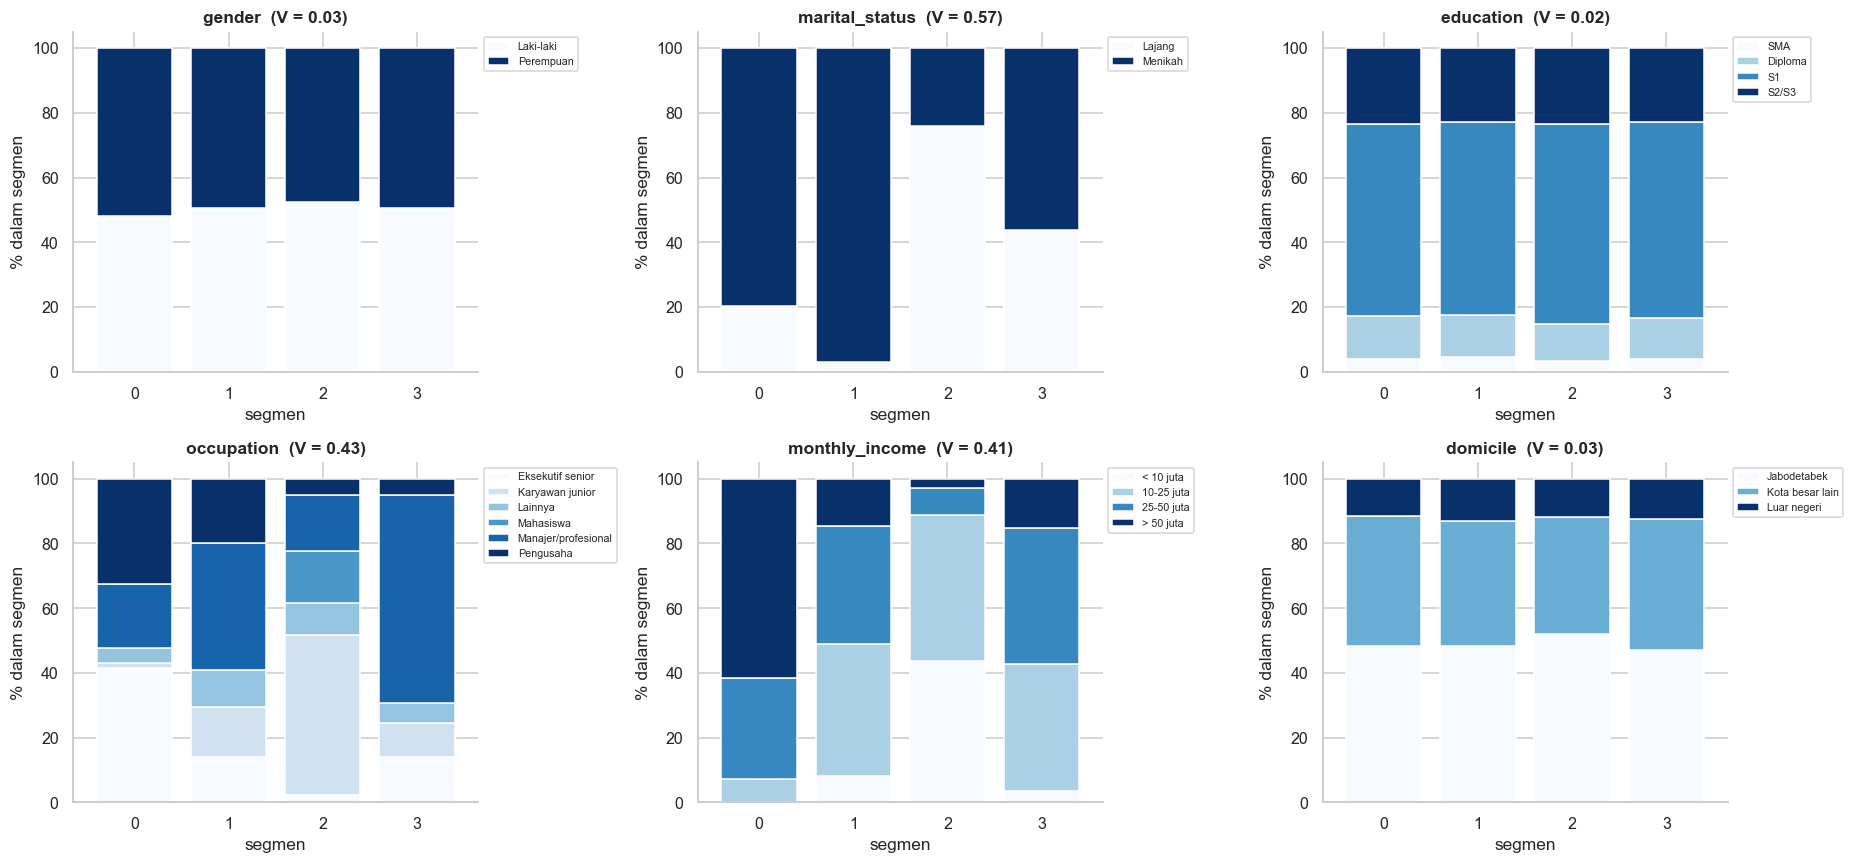

In [113]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, var in zip(axes.ravel(), DEMO_CATEGORICAL):
    ct_pct = fc.crosstab_pct(pool, pool["seg_id"], var, order=CATEGORY_ORDER.get(var))
    ct_pct.T.plot(kind="bar", stacked=True, ax=ax, colormap="Blues", edgecolor="white", width=0.8)
    ax.set_title(f"{var}  (V = {tab_cat.loc[var, 'cramers_v']:.2f})"); ax.set_xlabel("segmen"); ax.set_ylabel("% dalam segmen")
    ax.tick_params(axis="x", rotation=0); ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); fc.save_fig(fig, "08a_profil_demografi_id"); plt.show()

**Hasil & interpretasi:**
- **Membedakan (lolos Bonferroni, effect size kuat):** `marital_status` (V **0,575**), `occupation` (**0,435**), `monthly_income` (**0,412**).
- **Tidak membedakan:** `domicile` (V 0,030; p = 0,745), `gender` (0,028; p = 0,660), `education` (0,020; p = 0,985). Pada grafik, kolom `gender` hampir persis 50:50 di semua segmen. Syarat chi-square terpenuhi (0% sel dengan E < 5).
- Semua tabel silang yang signifikan dibaca di Step 7 saat segmen diberi nama.

In [114]:
for v in tab_cat.index[tab_cat["membedakan"]]:
    print(f"\n=== {v} (% di dalam segmen) ===")
    display(fc.crosstab_pct(pool, pool["seg_id"], v, order=CATEGORY_ORDER.get(v)).round(1))


=== marital_status (% di dalam segmen) ===


col_0,0,1,2,3
marital_status,,,,
Lajang,20.300,3.000,75.900,43.700
Menikah,79.700,97.000,24.100,56.300



=== occupation (% di dalam segmen) ===


col_0,0,1,2,3
occupation,,,,
Eksekutif senior,41.700,13.900,2.400,14.000
Karyawan junior,1.300,15.500,49.200,10.600
Lainnya,4.700,11.500,10.100,6.100
Mahasiswa,0.000,0.000,16.000,0.000
Manajer/profesional,19.700,39.400,17.400,64.200
Pengusaha,32.700,19.700,4.900,5.100



=== monthly_income (% di dalam segmen) ===


col_0,0,1,2,3
monthly_income,,,,
< 10 juta,0.000,8.200,43.700,3.500
10-25 juta,7.300,40.600,45.200,39.100
25-50 juta,31.000,36.400,8.300,42.000
> 50 juta,61.700,14.700,2.900,15.300


### Rangkuman Step 6
| Kelompok | Variabel yang **membedakan** (effect size besar) | Variabel yang **tidak** membedakan |
|---|---|---|
| Perilaku (16) | semua, terkuat: `ota_pct` (η² 0,83), `direct_pct` (0,81), `weekday_pct` (0,76) | – |
| Demografi numerik | `age` (η² 0,68), `num_children` (0,54) | – |
| Demografi kategorikal | `marital_status` (V 0,58), `occupation` (0,44), `monthly_income` (0,41) | `domicile`, `gender`, `education` (V ≈ 0,02–0,03, p > 0,6) |

- **Implikasi targeting:** usia, status/anak, pekerjaan, dan pendapatan layak dipakai untuk memahami dan menjangkau segmen; **gender, pendidikan, domisili tidak informatif**.
- **Validasi eksternal:** karena demografi tidak ikut membentuk cluster, perbedaan besarnya membuktikan bahwa segmen perilaku ini mencerminkan *kelompok orang yang berbeda*, bukan artefak algoritma.
- **Keterbatasan:** ini menunjukkan keterkaitan, bukan sebab-akibat; signifikansi variabel pembentuk cluster tidak independen.

---
# Step 7. Penamaan Segmen  *(Langkah 6 assignment)*

### Tujuan
Menerjemahkan angka menjadi **nama dan cerita** yang bisa dipahami manajemen non-teknis.

### Mekanisme penamaan (4 langkah)
1. **Cari ciri paling menonjol** tiap segmen dari z-score profil (nilai yang paling jauh dari 0, positif maupun negatif).
2. **Cek dengan demografi** (usia, anak, pekerjaan, pendapatan) agar ceritanya masuk akal.
3. **Pilih nama** yang menggambarkan *siapa mereka* dan *apa yang membedakan*, dalam kata yang dipahami manajemen.
4. **Uji pembeda:** setiap nama harus merujuk ciri yang tidak dimiliki segmen lain.

> Nama adalah **interpretasi**, bukan hasil pengukuran. Data tidak mengukur "tujuan perjalanan" atau "sensitivitas harga"; kita menyimpulkannya dari perilaku dan demografi.

### 7a. Langkah 1–2: ciri paling menonjol dan cek demografi

In [115]:
# Tiga ciri tertinggi dan terendah tiap segmen (dari z-score profil, Step 6a)
def ciri(row, n=3, tinggi=True):
    s = row.sort_values(ascending=not tinggi).head(n)
    return ", ".join(f"{v} ({z:+.2f})" for v, z in s.items())
ringkas_ciri = pd.DataFrame({
    "ciri tertinggi": zprof.apply(ciri, axis=1, tinggi=True),
    "ciri terendah":  zprof.apply(ciri, axis=1, tinggi=False),
})
pd.set_option("display.max_colwidth", 120)
ringkas_ciri

,ciri tertinggi,ciri terendah
0,"adr (+1.42), fnb_per_stay (+0.96), avg_los (+0.47)","ota_pct (-0.84), weekday_pct (-0.46), business_facility (-0.31)"
1,"family_facility (+1.32), avg_los (+1.08), lead_time (+0.98)","weekday_pct (-1.06), business_facility (-0.63), stays_per_year (-0.46)"
2,"ota_pct (+1.26), weekday_pct (-0.10), lead_time (-0.33)","avg_los (-0.66), adr (-0.59), business_facility (-0.53)"
3,"weekday_pct (+1.22), business_facility (+1.21), stays_per_year (+0.90)","ota_pct (-0.91), lead_time (-0.63), family_facility (-0.58)"


In [116]:
# Cek demografi per segmen
demo = pd.DataFrame({
    "usia rata-rata": pool.groupby("seg_id")["age"].mean(),
    "anak < 12 th": pool.groupby("seg_id")["num_children"].mean(),
    "% menikah": pool.groupby("seg_id")["marital_status"].apply(lambda s: (s == "Menikah").mean() * 100),
    "% penghasilan > 50 jt": pool.groupby("seg_id")["monthly_income"].apply(lambda s: (s == "> 50 juta").mean() * 100),
    "% penghasilan < 25 jt": pool.groupby("seg_id")["monthly_income"].apply(lambda s: s.isin(["< 10 juta", "10-25 juta"]).mean() * 100),
    "pekerjaan dominan": pool.groupby("seg_id")["occupation"].agg(lambda s: f"{s.value_counts().index[0]} ({s.value_counts(normalize=True).iloc[0]*100:.0f}%)"),
})
demo

,usia rata-rata,anak < 12 th,% menikah,% penghasilan > 50 jt,% penghasilan < 25 jt,pekerjaan dominan
seg_id,,,,,,
0,50.150,0.320,79.667,61.667,7.333,Eksekutif senior (42%)
1,41.533,1.926,96.982,14.688,48.893,Manajer/profesional (39%)
2,28.164,0.071,24.115,2.867,88.870,Karyawan junior (49%)
3,37.808,0.320,56.324,15.346,42.664,Manajer/profesional (64%)


**Hasil & interpretasi:**
- **Segmen 3:** hari kerja (+1,22), fasilitas bisnis (+1,21), frekuensi stay (+0,90); OTA (−0,91) dan lead time (−0,63) rendah. Demografi: usia 38, manajer/profesional **64%** → pelaku perjalanan dinas.
- **Segmen 0:** ADR (+1,42), F&B per stay (+0,96); OTA rendah (−0,84), hari kerja rendah (−0,46). Demografi: usia **50**, eksekutif senior + pengusaha, **62%** berpenghasilan > Rp50 juta, 80% menikah.
- **Segmen 1:** fasilitas keluarga (+1,32), lama menginap (+1,08), lead time (+0,98); hari kerja rendah (−1,06). Demografi: **97% menikah, rata-rata 1,93 anak** → keluarga dengan anak kecil.
- **Segmen 2:** satu-satunya ciri positif besar adalah OTA (+1,26); ADR (−0,59), lama menginap (−0,66), F&B (−0,45) rendah. Demografi: usia **28**, 76% lajang, **89%** berpenghasilan < Rp25 juta, satu-satunya yang berisi mahasiswa.

### 7b. Langkah 3–4: pemberian nama (aturan ditulis eksplisit, bukan di modul)
Pemberian nama dilakukan lewat aturan yang **bisa diperiksa**: tiap nama diberikan pada segmen yang paling menonjol pada variabel penanda, diproses dari yang paling unik. Segmen terakhir diberi nama **lewat eliminasi**, lalu kita **memverifikasi dengan bukti positif** bahwa eliminasi itu tepat (`assert`). Bila data berubah dan aturan tidak lagi cocok, sel ini akan gagal, bukan diam-diam memberi nama salah.

In [117]:
# Nama dan warna segmen: diketahui SETELAH membaca profil di 7a, jadi didefinisikan di sini
# Nama = akronim berbahasa Indonesia; kepanjangan ditulis eksplisit lalu DIVERIFIKASI mengeja namanya
KEPANJANGAN = {
    "SIBUK":  "Sering Inap untuk Bisnis & Urusan Kerja",
    "MAPAN":  "Menikmati Akomodasi Premium, Anggaran Nyaman",
    "RAMEAN": "Rencana Awal, Menginap Ekstra lama, Anak ikut, Nyaman",
    "CERMAT": "Cari Ekonomis, Reservasi Mayoritas lewat Agen Travel",
}
for nama, panjang in KEPANJANGAN.items():       # huruf awal kata berhuruf kapital harus membentuk nama
    assert "".join(w[0] for w in panjang.split() if w[0].isupper()) == nama, f"kepanjangan {nama} tidak mengeja namanya"
SEG_COLORS = {"SIBUK": "#1f4e79", "MAPAN": "#b8860b", "RAMEAN": "#2e8b57", "CERMAT": "#c0392b"}
ORDER = list(SEG_COLORS)

sisa, nama_seg = set(zprof.index), {}
def beri_nama(variabel, nama):
    kandidat = zprof.loc[sorted(sisa), variabel].idxmax()      # segmen tersisa yang paling tinggi pada variabel penanda
    nama_seg[int(kandidat)] = nama; sisa.discard(kandidat)

beri_nama("adr", "MAPAN")           # ADR tertinggi
beri_nama("business_facility", "SIBUK")   # fasilitas bisnis tertinggi
beri_nama("family_facility", "RAMEAN")      # fasilitas keluarga tertinggi
sisa_id = sisa.pop(); nama_seg[int(sisa_id)] = "CERMAT"   # sisanya, diverifikasi di bawah

# Verifikasi bukti POSITIF untuk segmen hasil eliminasi
assert zprof.loc[sisa_id, "ota_pct"] == zprof["ota_pct"].max(), "segmen sisa bukan yang ber-OTA tertinggi"
assert zprof.loc[sisa_id, "adr"] == zprof["adr"].min(), "segmen sisa bukan yang ber-ADR terendah"
print("Pemetaan:", nama_seg)
pool["segmen"] = pool["seg_id"].map(nama_seg)
fc.size_table(pool["segmen"]).loc[ORDER]

Pemetaan: {0: 'MAPAN', 3: 'SIBUK', 1: 'RAMEAN', 2: 'CERMAT'}


,n,persen
segmen,,
SIBUK,593,29.904
MAPAN,300,15.129
RAMEAN,497,25.063
CERMAT,593,29.904


**Hasil & interpretasi:** pemetaan: 0 → MAPAN (300; 15,1%), 1 → RAMEAN (497; 25,1%), 2 → CERMAT (593; 29,9%), 3 → SIBUK (593; 29,9%). Dua `assert` lolos: segmen hasil eliminasi memang yang ber-OTA **tertinggi** dan ber-ADR **terendah**, jadi nama "CERMAT" didukung bukti positif, bukan sekadar "sisa".

**Kepanjangan nama dan bukti datanya** (tiap nama harus bisa ditelusuri ke angka):

| Nama | Kepanjangan | Bukti utama di data |
|---|---|---|
| **SIBUK** | **S**ering **I**nap untuk **B**isnis & **U**rusan **K**erja | 14,4 stay/tahun, 85% malam di hari kerja, fasilitas bisnis tertinggi (z +1,21), lead time 7,6 hari |
| **MAPAN** | **M**enikmati **A**komodasi **P**remium, **A**nggaran **N**yaman | ADR tertinggi (Rp3,74 juta; z +1,42), F&B Rp2,38 juta/stay, 62% berpenghasilan > Rp50 juta |
| **RAMEAN** | **R**encana **A**wal, **M**enginap **E**kstra lama, **A**nak ikut, **N**yaman | lead time 49 hari, menginap terlama (3,6 malam), 1,93 anak < 12 tahun, fasilitas keluarga tertinggi (z +1,32) |
| **CERMAT** | **C**ari **E**konomis, **R**eservasi **M**ayoritas lewat **A**gen **T**ravel | ADR terendah (Rp0,63 juta), 76% pemesanan via OTA (z +1,26), usia 28, 89% berpenghasilan < Rp25 juta |

**Catatan pemilihan kata:** "akhir pekan" **tidak** dipakai untuk MAPAN karena tidak membedakan (malam akhir pekan MAPAN 59%, RAMEAN justru 75%); yang unik adalah tarif dan belanja. Untuk CERMAT dihindari kata "membandingkan aplikasi": perilaku membandingkan tidak diukur, dan segmen ini justru jarang memakai aplikasi ALL (2,2 sesi/bulan). Kata "Nyaman" pada MAPAN dan RAMEAN adalah pemanis; kenyamanan tidak diukur di data.

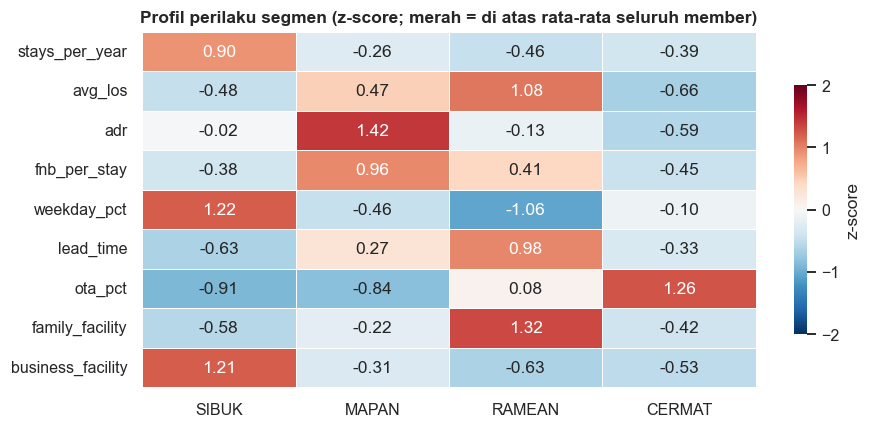

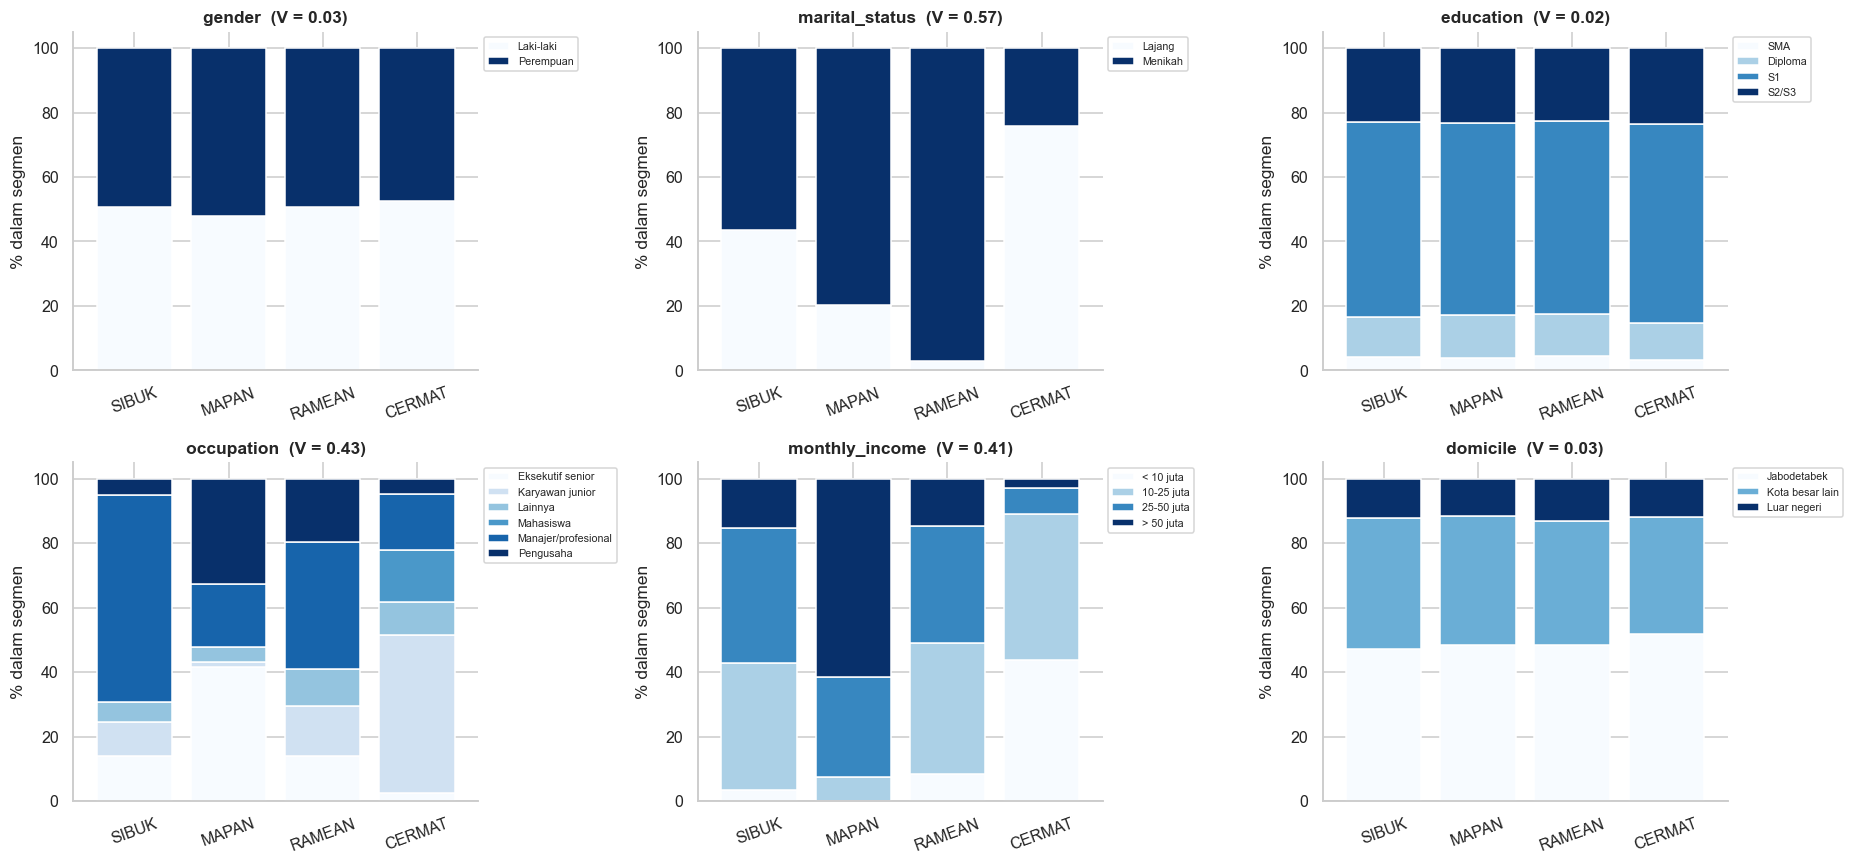

In [118]:
fig, ax = plt.subplots(figsize=(9, 4.2))
zp_named = fc.zscore_profile(pool, pool["segmen"], FINAL_VARS).loc[ORDER]
fc.plot_profile_heatmap(zp_named.T, ax=ax, title="Profil perilaku segmen (z-score; merah = di atas rata-rata seluruh member)")
fc.save_fig(fig, "07_profil_perilaku"); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, var in zip(axes.ravel(), DEMO_CATEGORICAL):
    ct_pct = fc.crosstab_pct(pool, pool["segmen"], var, order=CATEGORY_ORDER.get(var))[ORDER]
    ct_pct.T.plot(kind="bar", stacked=True, ax=ax, colormap="Blues", edgecolor="white", width=0.8)
    ax.set_title(f"{var}  (V = {tab_cat.loc[var, 'cramers_v']:.2f})"); ax.set_xlabel(""); ax.set_ylabel("% dalam segmen")
    ax.tick_params(axis="x", rotation=20); ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); fc.save_fig(fig, "08_profil_demografi"); plt.show()

In [119]:
# Ringkasan median (tahan outlier) untuk deskripsi kartu segmen
kunci = ["stays_per_year", "avg_los", "adr", "fnb_per_stay", "weekday_pct", "lead_time", "ota_pct",
         "family_facility", "business_facility", "app_sessions", "total_spend"]
ringkasan = pool.groupby("segmen").agg(n=("customer_id", "size"), **{c: (c, "median") for c in kunci}).loc[ORDER]
ringkasan.insert(1, "persen", ringkasan["n"] / ringkasan["n"].sum() * 100)
ringkasan.T

segmen,SIBUK,MAPAN,RAMEAN,CERMAT
n,593.000,300.000,497.000,593.000
persen,29.904,15.129,25.063,29.904
stays_per_year,12.000,4.000,2.000,3.000
avg_los,1.800,2.800,3.400,1.600
adr,"1,470,000.000","3,240,000.000","1,320,000.000","615,000.000"
fnb_per_stay,"256,000.000","1,825,500.000","1,310,000.000","148,000.000"
weekday_pct,86.600,40.100,23.800,50.600
lead_time,7.000,29.000,44.000,12.000
ota_pct,6.900,8.850,39.900,77.100
family_facility,0.100,0.620,2.500,0.310


**Hasil:** median per segmen: SIBUK 12 stay/tahun, 87% hari kerja, lead time 7 hari, OTA 7%; MAPAN 4 stay, ADR Rp3,24 juta (≈ 2,2× SIBUK), lead time 29 hari; RAMEAN 2 stay, 3,4 malam, 24% hari kerja, lead time 44 hari, OTA 40%; CERMAT 3 stay, ADR Rp615 ribu, OTA 77%.

### Kartu segmen (bahasa bisnis)
| Segmen | Ukuran | Ciri perilaku | Ciri demografi | Satu kalimat untuk manajemen |
|---|---|---|---|---|
| **SIBUK** | 30% | ±12–14 stay/tahun, 85% malam hari kerja, lead time ±7 hari, fasilitas bisnis tertinggi, ±83% booking langsung, aplikasi aktif | usia ±38, manajer/profesional (64%), penghasilan 10–50 jt | Pelaku perjalanan dinas yang menginap hampir tiap minggu, memesan mepet dan langsung ke Accor |
| **MAPAN** | 15% | hanya ±4 stay tetapi ADR ±Rp3,7 jt, F&B/spa tertinggi, 59% malam akhir pekan, lead time ±1 bulan, 81% booking langsung | usia ±50, eksekutif/pengusaha (74%), 62% > 50 jt, menikah | Pelancong mapan yang jarang menginap tetapi sangat bernilai per kunjungan |
| **RAMEAN** | 25% | fasilitas keluarga tertinggi, menginap terlama (±3,6 malam), 75% malam akhir pekan, lead time ±49 hari, OTA ±40% | usia ±42, 97% menikah, ±1,9 anak | Keluarga dengan anak kecil yang merencanakan liburan jauh hari |
| **CERMAT** | 30% | ADR terendah (±Rp0,6 jt), 76% via OTA, ±2 sesi aplikasi/bulan, belanja tambahan minim | usia ±28, lajang (76%), karyawan junior/mahasiswa, penghasilan < 25 jt | Anak muda berpenghasilan terbatas yang memesan lewat OTA dan jarang memakai aplikasi ALL |

### Tiga hal yang perlu diwaspadai
1. **Nama adalah interpretasi.** "Bisnis" disimpulkan dari hari kerja + fasilitas bisnis, "keluarga" dari anak + fasilitas keluarga. Untuk "CERMAT", belum ada data bahwa mereka responsif pada diskon; itu **hipotesis** (ADR rendah + OTA tinggi + pendapatan rendah).
2. **Klaim OTA untuk RAMEAN harus dinyatakan relatif.** Angkanya 40%, jauh di atas SIBUK (10%) dan MAPAN (12%), tetapi z-score-nya hanya **+0,08**, yaitu kira-kira rata-rata seluruh member karena CERMAT (76%) menarik rata-rata ke atas. Kalimat aman: "sekitar 40% pemesanan lewat OTA, jauh di atas dua segmen premium."
3. **Tidak semua ciri unik.** SIBUK ber-ADR sekitar rata-rata (z ≈ −0,02): bukan "hemat" dan bukan "mewah". Keunggulan mereka ada di **frekuensi**.

### Rangkuman Step 7
- Empat segmen dinamai dari ciri z-score yang paling menonjol, dicek dengan demografi, dengan aturan penamaan yang eksplisit dan terverifikasi (`assert`).
- **SIBUK** (30%), **MAPAN** (15%), **RAMEAN** (25%), **CERMAT** (30%).
- Nama = interpretasi; hipotesis "pencari harga" (CERMAT) dan "tujuan perjalanan" belum diukur langsung.

---
# Step 8. Daya Tarik Segmen, Prioritas, dan Usulan Program  *(Langkah 7 assignment)*

### Tujuan
Menjawab pertanyaan manajemen: **dengan anggaran terbatas, segmen mana yang digarap lebih dulu, dan dengan program apa?**

### Mekanisme: tiga kriteria daya tarik
| Kriteria | Ukuran | Bobot (asumsi) |
|---|---|---|
| **Ukuran** | jumlah member di segmen | 30% |
| **Nilai bagi Accor** | rata-rata `total_spend` per member (kamar + F&B + spa) | 40% |
| **Kemudahan dijangkau** | rata-rata dari `direct_pct` dan `app_sessions` (kanal milik Accor sendiri, tanpa komisi OTA) | 30% |

**Skala 1–5 (min-max antar segmen):** skor = 1 + 4 × (nilai − min) ÷ (maks − min); segmen terendah mendapat 1, tertinggi 5. **Skor total = Σ bobot × skor kriteria.** Karena bobot 30/40/30 adalah **asumsi**, hasilnya diuji dengan lima skema bobot (**uji sensitivitas**).

In [120]:
# Bobot daya tarik: asumsi manajemen, ditetapkan di sini (bukan di modul)
WEIGHTS = {"ukuran": 0.30, "nilai": 0.40, "akses": 0.30}
# Kolom yang mewakili tiap kriteria juga ditetapkan di sini
KRITERIA = dict(value_col="total_spend", access_cols=["direct_pct", "app_sessions"], extra_cols=["ota_pct"])
att = fc.attractiveness_table(pool, seg_col="segmen", weights=WEIGHTS, **KRITERIA)
att[["n_member", "pct_member", "avg_total_spend", "revenue_share_pct", "direct_pct", "ota_pct", "app_sessions",
     "skor_ukuran", "skor_nilai", "skor_akses", "skor_total", "peringkat"]].style.format(
    {"n_member": "{:,.0f}", "pct_member": "{:.1f}", "avg_total_spend": "{:,.0f}", "revenue_share_pct": "{:.1f}",
     "direct_pct": "{:.1f}", "ota_pct": "{:.1f}", "app_sessions": "{:.1f}", "skor_ukuran": "{:.2f}", "skor_nilai": "{:.2f}",
     "skor_akses": "{:.2f}", "skor_total": "{:.2f}", "peringkat": "{:.0f}"})

,n_member,pct_member,avg_total_spend,revenue_share_pct,direct_pct,ota_pct,app_sessions,skor_ukuran,skor_nilai,skor_akses,skor_total,peringkat
segmen,,,,,,,,,,,,
SIBUK,593,29.9,"44,704,320",45.3,82.6,10.0,8.0,5.00,3.48,5.00,4.39,1
MAPAN,300,15.1,"69,778,803",35.8,80.6,12.1,7.8,1.00,5.00,4.84,3.75,2
RAMEAN,497,25.1,"17,407,400",14.8,52.6,39.9,5.3,3.69,1.82,3.14,2.78,3
CERMAT,593,29.9,"3,985,197",4.0,17.5,75.5,2.2,5.00,1.00,1.00,2.20,4


In [121]:
# Verifikasi manual satu angka: skor "nilai" segmen RAMEAN
v = att["avg_total_spend"]
manual = 1 + 4 * (v["RAMEAN"] - v.min()) / (v.max() - v.min())
print(f"skor_nilai RAMEAN (manual) = {manual:.2f} | tabel = {att.loc['RAMEAN','skor_nilai']:.2f}")
bw = att.loc["SIBUK"]
print(f"skor_total SIBUK (manual) = {0.30*bw.skor_ukuran + 0.40*bw.skor_nilai + 0.30*bw.skor_akses:.2f} | tabel = {bw.skor_total:.2f}")

skor_nilai RAMEAN (manual) = 1.82 | tabel = 1.82
skor_total SIBUK (manual) = 4.39 | tabel = 4.39


**Hasil & interpretasi:**
- **Nilai:** dua segmen teratas (SIBUK + MAPAN) menyumbang **±81% total belanja** (45,4% + 35,8%) dengan hanya 45% member. Rata-rata belanja per member: MAPAN Rp69,8 juta > SIBUK Rp44,7 juta > RAMEAN Rp17,4 juta > CERMAT Rp4,0 juta.
- **Skor total:** SIBUK **4,39** (peringkat 1), MAPAN **3,75** (2), RAMEAN **2,78** (3), CERMAT **2,20** (4). Hitungan manual cocok dengan tabel (RAMEAN nilai = 1,82; SIBUK total = 4,39).
- SIBUK unggul karena **ukuran terbesar (skor 5,0)**, **jangkauan tertinggi (5,0)**, dan nilai tinggi (3,48). MAPAN unggul pada **nilai (5,0)** tetapi ukurannya terkecil (1,0).

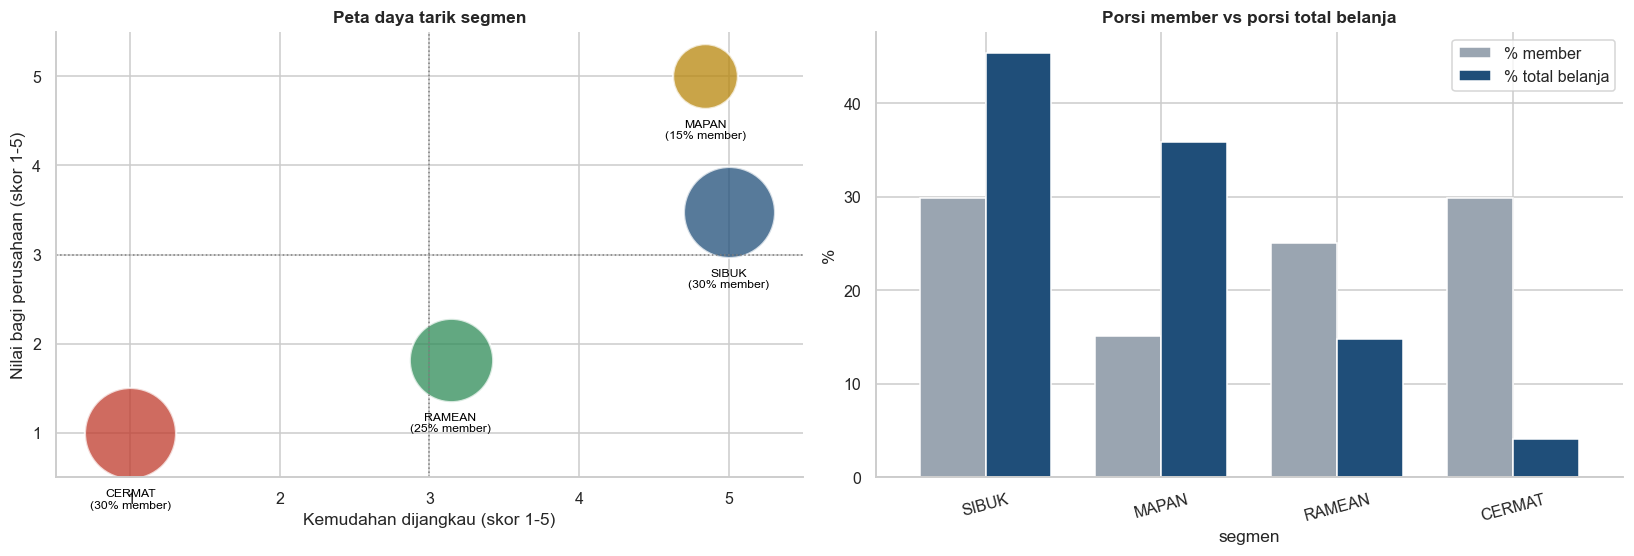

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
fc.plot_attractiveness_bubble(att, colors=SEG_COLORS, ax=axes[0]); axes[0].set_title("Peta daya tarik segmen")
share = att.loc[ORDER, ["pct_member", "revenue_share_pct"]]
share.plot(kind="bar", ax=axes[1], color=["#9aa5b1", "#1f4e79"], width=0.75)
axes[1].set_title("Porsi member vs porsi total belanja"); axes[1].set_ylabel("%"); axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(["% member", "% total belanja"])
plt.tight_layout(); fc.save_fig(fig, "09_daya_tarik"); plt.show()

**Hasil:** di peta (kanan atas = bernilai tinggi dan mudah dijangkau), **SIBUK** dan **MAPAN** berada di kuadran atas-kanan; RAMEAN di tengah; CERMAT di kiri bawah. Pada grafik batang, SIBUK menyumbang 45% belanja dari 30% member, MAPAN **36% dari hanya 15% member**, sedangkan CERMAT hanya 4% belanja dari 30% member.

### Uji sensitivitas bobot
Bila bobot digeser, apakah peringkat berubah? Lima skema dideklarasikan eksplisit di bawah (jangkar: skema default dan skema yang menekankan masing-masing kriteria).

In [123]:
SCHEMES = {
    "Default (30/40/30)": {"ukuran": 0.30,  "nilai": 0.40,  "akses": 0.30},
    "Bobot sama":         {"ukuran": 1 / 3, "nilai": 1 / 3, "akses": 1 / 3},
    "Fokus nilai":        {"ukuran": 0.20,  "nilai": 0.60,  "akses": 0.20},
    "Fokus ukuran":       {"ukuran": 0.60,  "nilai": 0.20,  "akses": 0.20},
    "Fokus jangkauan":    {"ukuran": 0.20,  "nilai": 0.20,  "akses": 0.60},
}
sens = fc.weight_sensitivity(pool, seg_col="segmen", schemes=SCHEMES, **KRITERIA).loc[ORDER]
display(sens)
top = att.index[0]
print(f"{top}: peringkat 1 pada {(sens.loc[top] == 1).sum()} dari {sens.shape[1]} skema")

,Default (30/40/30),Bobot sama,Fokus nilai,Fokus ukuran,Fokus jangkauan
segmen,,,,,
SIBUK,1,1,2,1,1
MAPAN,2,2,1,4,2
RAMEAN,3,3,3,3,3
CERMAT,4,4,4,2,4


SIBUK: peringkat 1 pada 4 dari 5 skema


**Hasil & interpretasi:** **SIBUK** peringkat 1 pada **4 dari 5 skema**; hanya turun ke peringkat 2 ketika bobot nilai dinaikkan ke 60% (saat itu MAPAN naik ke 1). **MAPAN** selalu di dua besar kecuali saat ukuran diutamakan (turun ke 4). **RAMEAN** selalu peringkat 3. **CERMAT** peringkat 4 di empat skema dan hanya naik ke 2 bila ukuran diberi bobot 60%. Jadi **urutan dua teratas tahan terhadap perubahan bobot**.

### Keterbatasan skor yang perlu diakui
1. **Skala min-max itu relatif:** MAPAN mendapat skor ukuran 1,00 padahal punya 300 member (15%); skor 1 hanya berarti "terkecil di antara empat".
2. **"Nilai" = pendapatan, bukan laba:** tidak ada data margin atau biaya.
3. **"Dijangkau" adalah proksi** (booking langsung + aplikasi), bukan data izin komunikasi atau respons kampanye.
4. **Skor tidak menangkap potensi perubahan:** SIBUK sudah ±83% memesan langsung, jadi ruang menggeser dari OTA kecil; nilainya ada di retensi dan frekuensi.

### Segmen prioritas dan usulan program pemasaran
- **Prioritas 1: SIBUK.** Terbesar, 45% pendapatan, paling mudah dijangkau; risiko kehilangannya paling mahal.
- **Prioritas 2: MAPAN.** 15% member tetapi 36% pendapatan, belanja per member tertinggi; ukuran kecil → pendekatan personal.
- **Peluang opsional: RAMEAN.** Sekitar 40% pesanan lewat OTA (relatif tinggi), kandidat utama untuk isu "porsi OTA naik" di soal; garap dengan biaya rendah dan musiman.
- **Tidak diprioritaskan: CERMAT.** Belanja rata-rata ±Rp4 juta, 76% via OTA, jarang membuka aplikasi; cukup dijaga dengan komunikasi otomatis berbiaya rendah.

Setiap elemen program ditelusuri ke temuan data (**insight → rekomendasi**):

| | SIBUK | MAPAN |
|---|---|---|
| **Sasaran** | Naikkan frekuensi dan retensi; pertahankan booking langsung | Naikkan frekuensi dan belanja spa/F&B |
| **Dasar data** | 14 stay/tahun, 85% hari kerja, 83% langsung, 8 sesi aplikasi/bulan, lead time 7 hari | hanya 4 stay tetapi ADR Rp3,7 juta, spa ±Rp1,5 juta/stay, F&B Rp2,4 juta/stay, lead time 31 hari, 59% akhir pekan |
| **Penawaran** | Express check-in/late check-out, bonus poin untuk stay hari kerja berturut-turut, upgrade otomatis di stay ke-N, rate korporat di aplikasi | Paket weekend escape (spa + dining), akses pengalaman eksklusif, tukar poin ke upgrade suite |
| **Kanal & waktu** | Aplikasi dan notifikasi, dikirim awal pekan (Minggu sore/Senin pagi) karena pemesanan mepet | Personal (concierge/email), 3–4 minggu sebelum akhir pekan panjang |
| **KPI** | Stay per member, retensi, share booking langsung, poin ditukar | Stay per member, belanja spa/F&B per stay, ADR |

**Opsional, RAMEAN:** paket keluarga (kids club, anak menginap gratis) **eksklusif via website/aplikasi ALL**, dikirim 6–8 minggu sebelum libur sekolah (lead time 44–49 hari); KPI: turunnya `ota_pct`, konversi direct.

*Catatan:* ini rekomendasi kualitatif; idealnya diuji kecil (A/B test) dan ROI-nya dihitung dengan data biaya kampanye (belum tersedia di data ini).

### Rangkuman Step 8
- **Skor daya tarik:** SIBUK 4,39 > MAPAN 3,75 > RAMEAN 2,78 > CERMAT 2,20 (bobot 30/40/30).
- **Sensitivitas:** SIBUK #1 pada 4/5 skema; MAPAN #2 (atau #1 bila nilai ditekankan); RAMEAN selalu #3.
- **Rekomendasi:** fokus pada **SIBUK** (retensi/frekuensi) dan **MAPAN** (frekuensi dan belanja penunjang); RAMEAN sebagai peluang berbiaya rendah untuk menekan OTA; CERMAT dijaga minimal.

---
# Rangkuman Keseluruhan

**Alur cerita satu kalimat:** *bersihkan data → pilih variabel non-redundan → temukan 4 segmen yang stabil di dua sampel → profilkan dan uji secara statistik → beri nama dari ciri dan demografi → prioritaskan dua segmen bernilai tinggi dan mudah dijangkau.*

| Step | Temuan utama |
|---|---|
| 1 | 17 baris anomali dibuang (A1 = 991, A2 = 992); `points_earned` = 0,0001 × `total_spend` |
| 2 | 16 → 9 variabel (VIF ≤ 5,5); 12 variabel miring di-log |
| 3 | Ward + Euclidean; k = 4 (lonjakan agglomeration +184%); ukuran 150 / 249 / 296 / 296 |
| 4 | K-means (k-means++, `n_init` = 30) di A2; WSS 2.087,5; ukuran 150 / 248 / 297 / 297 |
| 5 | Konsisten dan stabil: ARI = 1,00; selisih centroid maks 0,06 SD; spesifikasi naif gagal (cluster 1 dan 10 orang) |
| 6 | Pembeda terkuat: `ota_pct`, `direct_pct`, `weekday_pct`; demografi membedakan: usia, anak, status nikah, pekerjaan, pendapatan; **tidak**: gender, pendidikan, domisili |
| 7 | SIBUK, MAPAN, RAMEAN, CERMAT |
| 8 | Prioritas: SIBUK (45% pendapatan) dan MAPAN (36% pendapatan) |

### Keterbatasan yang perlu dinyatakan
- Batas anomali (terutama `avg_los > 30`) dan toleransi identitas adalah keputusan penilaian.
- k = 3 sedikit lebih tinggi pada silhouette/CH; pilihan k = 4 bertumpu pada lonjakan agglomeration dan alasan bisnis.
- Signifikansi variabel pembentuk cluster tidak independen; validasi independen ada pada demografi.
- Nama segmen adalah interpretasi; "pencari harga" (CERMAT) dan "tujuan perjalanan" belum diukur langsung.
- Nilai segmen diukur dari pendapatan (bukan laba); bobot daya tarik adalah asumsi; rekomendasi belum diuji coba.

## Ekspor Hasil
Simpan data berlabel dan tabel utama ke Excel (lampiran/bahan slide).

In [124]:
with pd.ExcelWriter("hasil_segmentasi_accor.xlsx") as xw:
    pool[["customer_id", "source", "seg_id", "segmen"] + BEHAVIOR_VARS + DEMO_NUMERIC + DEMO_CATEGORICAL].to_excel(xw, sheet_name="data_berlabel", index=False)
    ringkasan.to_excel(xw, sheet_name="ringkasan_segmen")
    tab_beh.to_excel(xw, sheet_name="uji_perilaku"); tab_num.to_excel(xw, sheet_name="uji_demografi_numerik")
    tab_cat.to_excel(xw, sheet_name="uji_demografi_kategorikal")
    att.to_excel(xw, sheet_name="daya_tarik"); sens.to_excel(xw, sheet_name="sensitivitas_bobot")
    cmp_spec.astype(str).to_excel(xw, sheet_name="perbandingan_spesifikasi")
print("Tersimpan: hasil_segmentasi_accor.xlsx dan folder figures/")

Tersimpan: hasil_segmentasi_accor.xlsx dan folder figures/
